# 2 — Transforms and Forward Kinematics

Where is the foot? · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/02-transforms/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## One question, all week

> Given the joint angles, **where is the foot?**

That is *forward kinematics*. It sounds like bookkeeping, and it is —
but nothing above it works without it.

- Week 3 inverts it to decide joint angles from a desired foot position
- Week 4 uses that to place footsteps
- Week 12 feeds it into a policy’s observations

Today you will work it out **on paper for a two-link leg**, then write
it in code for all six joints, and check it against MuJoCo to the last
decimal place.

------------------------------------------------------------------------

## Why this is a question at all

A real robot does not know where its foot is. It knows **only what its
sensors report**, and in each leg joint sits an encoder reporting one
number: an angle.

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import mujoco
from soc4180 import kinematics as kin

model = soc4180.load_g1()
data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)

idx = kin.leg_qpos_indices(model, "left")
crouch = [-0.35, 0.0, 0.0, 0.70, -0.35, 0.0]

print("what the left leg's six encoders report, in the crouch pose:")
for name, angle in zip(kin.LEG_JOINTS, crouch):
    print(f"   {name:20s} {angle:+.2f} rad  = {np.degrees(angle):+6.1f} deg")

what the left leg's six encoders report, in the crouch pose:
   hip_pitch_joint      -0.35 rad  =  -20.1 deg
   hip_roll_joint       +0.00 rad  =   +0.0 deg
   hip_yaw_joint        +0.00 rad  =   +0.0 deg
   knee_joint           +0.70 rad  =  +40.1 deg
   ankle_pitch_joint    -0.35 rad  =  -20.1 deg
   ankle_roll_joint     +0.00 rad  =   +0.0 deg

Six numbers. Nowhere among them is a position. **Forward kinematics is
the function that turns those six angles into “the foot is here.”**

------------------------------------------------------------------------

## The names you will meet today

Week 1 split the world in two: **`model`** is the robot (constants from
the file, never change), **`data`** is this instant (changes every
step). Every array below lives in one or the other, and there is a rule
for telling which.

**An `x` in front means “computed, in world coordinates”.** No `x` means
“declared in the MJCF, relative to the parent”.

| Declared — in `model` | Computed — in `data` |
|------------------------------------|------------------------------------|
| `body_pos[b]`, `body_quat[b]` — link’s fixed offset from its **parent** | `xpos[b]`, `xmat[b]` — where body `b` **actually is**, in world |
| `site_pos[s]` — a marker’s fixed offset inside its body | `site_xpos[s]`, `site_xmat[s]` — where that marker actually is |
| `jnt_pos[j]`, `jnt_axis[j]` — where the joint sits, and what it turns about | `qpos` — the current angles |

In [2]:
b = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "left_knee_link")
s = kin.foot_site_id(model, "left")

print("model.body_pos [declared, from its parent] :", np.round(model.body_pos[b], 4))
print("data .xpos     [computed, in world]        :", np.round(data.xpos[b], 4))
print()
print("model.site_pos [declared, inside its body] :", np.round(model.site_pos[s], 4))
print("data .site_xpos[computed, in world]        :", np.round(data.site_xpos[s], 4))
print("data .site_xmat[computed, 3x3 flattened]   :", np.round(data.site_xmat[s], 3))

model.body_pos [declared, from its parent] : [-0.0783  0.0021 -0.1773]
data .xpos     [computed, in world]        : [-0.      0.1186  0.3507]

model.site_pos [declared, inside its body] : [0. 0. 0.]
data .site_xpos[computed, in world]        : [-0.      0.1185  0.0331]
data .site_xmat[computed, 3x3 flattened]   : [1. 0. 0. 0. 1. 0. 0. 0. 1.]

**`mujoco.mj_forward(model, data)` is what connects the columns.** It
reads `data.qpos` and fills in every `x` quantity. In other words:
*MuJoCo already has forward kinematics, and `mj_forward` is it.* Today
you write your own and check it against MuJoCo’s, which is why we can
demand agreement to the last decimal.

(Functions beginning `mju_` are small maths utilities — quaternion and
matrix conversions. Each is introduced where it is first needed.)

------------------------------------------------------------------------

## …and the helpers that do the index bookkeeping

MuJoCo addresses everything by integer id, so `soc4180.kinematics`
(imported as `kin`) carries the lookups for the left and right legs.
Four you will see all day:

In [3]:
print("kin.LEG_JOINTS            :", kin.LEG_JOINTS)
print("kin.leg_chain(model,'left'):", kin.leg_chain(model, "left"), " <- body ids, hip to foot")
print("kin.foot_site_id(...)      :", kin.foot_site_id(model, "left"), " <- the site id")
print()
print("kin.leg_qpos_indices(...)  :", kin.leg_qpos_indices(model, "left"), " <- slots in qpos (positions)")
print("kin.leg_dof_indices(...)   :", kin.leg_dof_indices(model, "left"), " <- slots in qvel (velocities)")

kin.LEG_JOINTS            : ('hip_pitch_joint', 'hip_roll_joint', 'hip_yaw_joint', 'knee_joint', 'ankle_pitch_joint', 'ankle_roll_joint')
kin.leg_chain(model,'left'): [2, 3, 4, 5, 6, 7]  <- body ids, hip to foot
kin.foot_site_id(...)      : 1  <- the site id

kin.leg_qpos_indices(...)  : [ 7  8  9 10 11 12]  <- slots in qpos (positions)
kin.leg_dof_indices(...)   : [ 6  7  8  9 10 11]  <- slots in qvel (velocities)

**Look at those last two: `7..12` against `6..11`.** The same six joints
have different addresses in position space and velocity space, off by
one — because the floating base spends **7** numbers on position and
only **6** on velocity. That is the `nq` versus `nv` gap of Week 1,
showing up as an indexing hazard you will hit if you mix them.

`soc4180.keyframe_data(model, "stand")` gives a fresh `data` already
posed at a named keyframe — a shortcut for `MjData` plus a copy of
`key_qpos`.

------------------------------------------------------------------------

## What those six numbers do

Only the **left** leg’s six angles change below. The right leg is
untouched, so you can use it as a ruler:

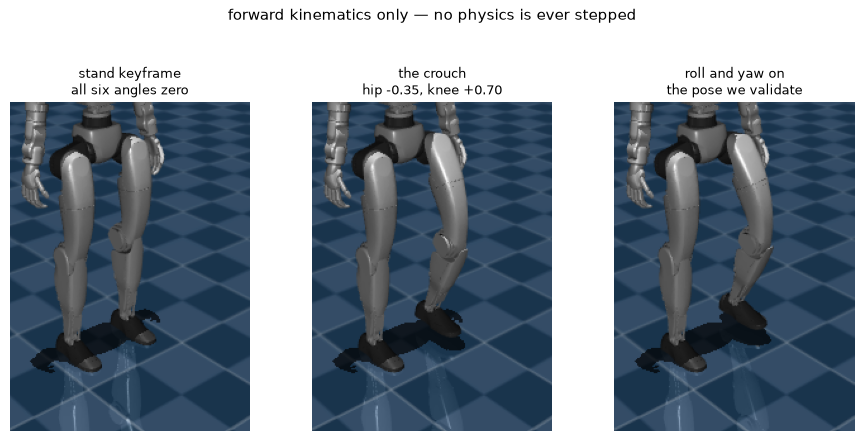

In [4]:
import matplotlib.pyplot as plt

shots = [("stand keyframe\nall six angles zero",  [0, 0, 0, 0, 0, 0]),
         ("the crouch\nhip -0.35, knee +0.70",    crouch),
         ("roll and yaw on\nthe pose we validate", [-0.30, 0.10, 0.05, 0.70, -0.35, 0.02])]

poses = []
for _, angles in shots:
    q = model.key_qpos[0].copy()
    q[idx] = angles
    poses.append(q)

frames = soc4180.render_poses(model, poses, width=380, height=480)

fig, axs = plt.subplots(1, 3, figsize=(9.6, 4.6))
for ax, (label, _), frame in zip(axs, shots, frames):
    ax.imshow(frame[185:445, 105:295])       # crop to the legs
    ax.set_title(label, fontsize=9.5)
    ax.axis("off")
fig.suptitle("forward kinematics only — no physics is ever stepped", fontsize=11, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

Nothing here is *simulated*. Each pose is placed and drawn. Kinematics
is a statement about **geometry**, not about balance — a pose can be
perfectly valid and still be one the robot could never hold.

------------------------------------------------------------------------

## Frames: a position needs a “relative to what”

Ask where your phone is. *On the desk* — but the desk is in a room, in a
moving building, on a spinning planet. Every answer is relative to
something you did not say out loud.

Robotics makes it explicit. A **frame** is an origin plus three axes,
and every position is measured in some frame:

- **world** — fixed to the ground, never moves
- **pelvis** — the robot’s own body frame, which moves with the robot
- one frame per link — thigh, shin, foot, each fixed to its own piece of
  metal

“The foot is at $(0, 0.12, 0.03)$” is only true in a *stated* frame.
Most robotics bugs are one number used in the wrong one, and they do not
look like bugs — they look like a robot that is slightly, confusingly
wrong.

------------------------------------------------------------------------

## The same foot, three frames

One physical point. Three legitimate, different answers:

In [5]:
def quat2mat(q):
    """MuJoCo quaternion (w, x, y, z) -> 3x3 rotation matrix."""
    out = np.zeros(9)
    mujoco.mju_quat2Mat(out, np.asarray(q, float))
    return out.reshape(3, 3)

foot_world = data.site_xpos[kin.foot_site_id(model, "left")]
pelvis_pos, pelvis_rot = data.qpos[:3], quat2mat(data.qpos[3:7])
hip_world = data.xpos[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "left_hip_pitch_link")]

print(f"in the WORLD frame        : {np.round(foot_world, 4)}")
print(f"in the PELVIS frame       : {np.round(pelvis_rot.T @ (foot_world - pelvis_pos), 4)}")
print(f"relative to the HIP joint : {np.round(foot_world - hip_world, 4)}")

in the WORLD frame        : [-0.      0.1185  0.0331]
in the PELVIS frame       : [-0.      0.1185 -0.7569]
relative to the HIP joint : [-0.      0.0541 -0.6542]

The world answer says the foot is 3 cm above the floor. The pelvis
answer says it is 76 cm below the pelvis origin (the pelvis stands at
$z = 0.79$ m), and the hip answer 65 cm below the hip joint. **All three
are correct.** None is usable without its label.

The pelvis line is not a subtraction alone: it is
`pelvis_rot.T @ (...)`, an *inverse transform*. The slide *Undoing a
transform* below derives why it has that shape.

------------------------------------------------------------------------

## Three arrows, one foot

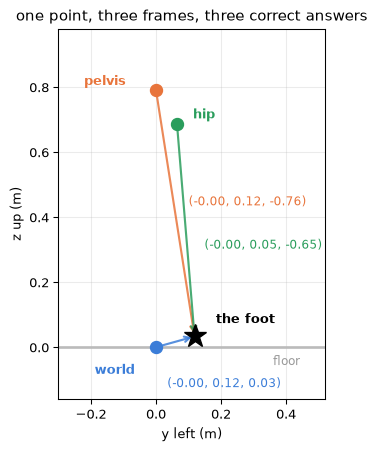

In [6]:
hip_body = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "left_hip_pitch_link")
#                name,      origin,               colour,    name offset, vector offset
origins = [("world",  np.zeros(3),          "#3b7dd8", (-46, -20), (-6, -34)),
           ("pelvis", data.qpos[:3],        "#e8743b", (-54,   4), (10,   6)),
           ("hip",    data.xpos[hip_body],  "#2a9d5c", ( 12,   4), (14, -14))]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.axhline(0, color="#bbb", lw=2)
ax.text(0.36, -0.055, "floor", color="#999", fontsize=9)
for name, o, colour, name_off, vec_off in origins:
    ax.plot(o[1], o[2], "o", ms=9, color=colour, zorder=4)
    ax.annotate(name, (o[1], o[2]), textcoords="offset points", xytext=name_off,
                color=colour, fontsize=10, weight="bold")
    ax.annotate("", xy=(foot_world[1], foot_world[2]), xytext=(o[1], o[2]),
                arrowprops=dict(arrowstyle="->", color=colour, lw=1.6, alpha=0.85))
    v = foot_world - o
    ax.annotate(f"({v[0]:.2f}, {v[1]:.2f}, {v[2]:.2f})",
                ((o[1] + foot_world[1]) / 2, (o[2] + foot_world[2]) / 2),
                textcoords="offset points", xytext=vec_off, color=colour, fontsize=9)
ax.plot(foot_world[1], foot_world[2], "*", ms=18, color="k", zorder=5)
ax.annotate("the foot", (foot_world[1], foot_world[2]), textcoords="offset points",
            xytext=(16, 10), fontsize=10, weight="bold")
ax.set_xlim(-0.30, 0.52); ax.set_ylim(-0.16, 0.98); ax.set_aspect("equal")
ax.set_xlabel("y left (m)"); ax.set_ylabel("z up (m)")
ax.set_title("one point, three frames, three correct answers", fontsize=11)
ax.grid(alpha=0.25); fig.tight_layout(); plt.show()

The arrows differ; the star does not move. **A frame is a question, not
a place.**

------------------------------------------------------------------------

## Colour code for the week

The same colours mean the same things in every equation from here on,
and in the drawings built for them:

| symbol | meaning |
|------------------------------------|------------------------------------|
| <span style="color:#3b7dd8">blue</span> ${\color{#3b7dd8}{q,\ \theta}}$ | a **joint angle** — what an encoder reports |
| <span style="color:#c0392b">red</span> ${\color{#c0392b}{\mathbf{p},\ \mathbf{x}}}$ | a **point** we want to locate — usually the foot |
| <span style="color:#e8743b">orange</span> ${\color{#e8743b}{R}}$ | a **rotation**: a $3\times3$ matrix, how a frame is turned |
| <span style="color:#2a9d5c">green</span> ${\color{#2a9d5c}{\mathbf{t}}}$ | a **translation**: where a frame’s origin is |
| <span style="color:#8e44ad">purple</span> ${\color{#8e44ad}{T}}$ | a **transform**: rotation and translation in one $4\times4$ matrix |

Blue angles and a red foot are week 3’s choice too, so the colours carry
over.

**Subscripts name two frames, read right to left.**
${\color{#e8743b}{R_{ab}}}$ and ${\color{#2a9d5c}{\mathbf{t}_{ab}}}$
describe frame $b$ *as seen from* frame $a$: they take a point written
in $b$’s coordinates and return it in $a$’s;
${\color{#c0392b}{\mathbf{p}_b}}$ is a point written in $b$. In
${\color{#e8743b}{R_{ab}}}{\color{#c0392b}{\mathbf{p}_b}}$ the inner
letters match — the $b$’s “cancel”, leaving $a$. Inner letters that do
not match are a bug.

------------------------------------------------------------------------

## A rotation matrix is where the axes land

What *is* the $3\times3$ matrix ${\color{#e8743b}{R}}$? Three steps, no
memorising:

**Step 1 — every vector is a mix of the three axes.** With
$\mathbf{e}_x = (1,0,0)$, $\mathbf{e}_y = (0,1,0)$,
$\mathbf{e}_z = (0,0,1)$:
$\;\mathbf{v} = v_x\,\mathbf{e}_x + v_y\,\mathbf{e}_y + v_z\,\mathbf{e}_z$.

**Step 2 — a rotation turns a mix into the same mix of turned axes.**
Turning a rigid object does not stretch it, so
$\;{\color{#e8743b}{R}}\mathbf{v} = v_x\,({\color{#e8743b}{R}}\mathbf{e}_x) + v_y\,({\color{#e8743b}{R}}\mathbf{e}_y) + v_z\,({\color{#e8743b}{R}}\mathbf{e}_z)$.

**Step 3 — so the columns of ${\color{#e8743b}{R}}$ are the turned
axes.**
$\;{\color{#e8743b}{R}} = \big[\,{\color{#e8743b}{R}}\mathbf{e}_x \;\big|\; {\color{#e8743b}{R}}\mathbf{e}_y \;\big|\; {\color{#e8743b}{R}}\mathbf{e}_z\,\big]$.
Column 1 is where $x$ ends up, column 2 where $y$ ends up, column 3
where $z$ ends up.

Now read the three basic rotations off a drawing (next slide). Turn by
${\color{#3b7dd8}{\theta}}$ about $z$: $x$ lands at
$(\cos{\color{#3b7dd8}{\theta}}, \sin{\color{#3b7dd8}{\theta}}, 0)$, $y$
at $(-\sin{\color{#3b7dd8}{\theta}}, \cos{\color{#3b7dd8}{\theta}}, 0)$,
and $z$ stays. Stack those as columns:

$$R_z({\color{#3b7dd8}{\theta}}) = \begin{bmatrix} \cos\theta & -\sin\theta & 0\\ \sin\theta & \cos\theta & 0\\ 0&0&1\end{bmatrix}\quad
R_x({\color{#3b7dd8}{\theta}}) = \begin{bmatrix} 1&0&0\\ 0&\cos\theta & -\sin\theta\\ 0&\sin\theta & \cos\theta\end{bmatrix}\quad
R_y({\color{#3b7dd8}{\theta}}) = \begin{bmatrix} \cos\theta & 0 & \sin\theta\\ 0&1&0\\ -\sin\theta & 0 & \cos\theta\end{bmatrix}$$

$R_y$ looks as if its minus sign is in the wrong corner. It is not — the
drawing shows why.

------------------------------------------------------------------------

## $R_z$ and $R_y$, drawn

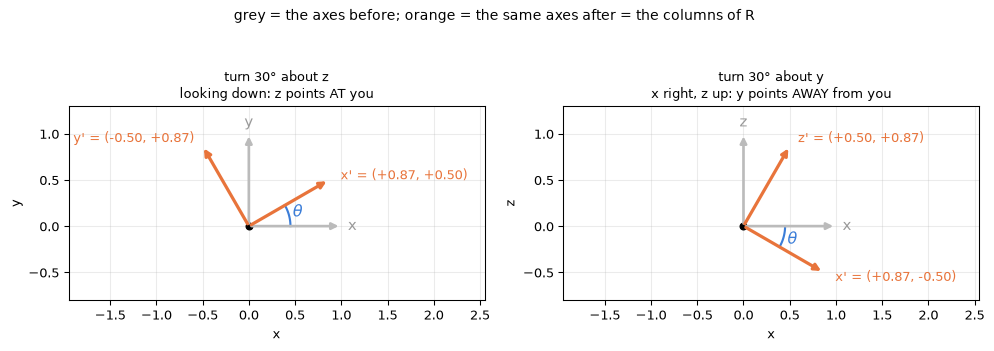

In [7]:
import matplotlib.pyplot as plt

def Rx(t): return np.array([[1, 0, 0], [0, np.cos(t), -np.sin(t)], [0, np.sin(t), np.cos(t)]])
def Ry(t): return np.array([[np.cos(t), 0, np.sin(t)], [0, 1, 0], [-np.sin(t), 0, np.cos(t)]])
def Rz(t): return np.array([[np.cos(t), -np.sin(t), 0], [np.sin(t), np.cos(t), 0], [0, 0, 1]])

th30 = np.radians(30)
panels = [(Rz(th30), (0, 1), "x", "y", "turn 30° about z\nlooking down: z points AT you"),
          (Ry(th30), (0, 2), "x", "z", "turn 30° about y\nx right, z up: y points AWAY from you")]

fig, axs = plt.subplots(1, 2, figsize=(10.4, 3.9))
for ax, (R, (i, j), n1, n2, title) in zip(axs, panels):
    for col, name in ((i, n1), (j, n2)):
        before = np.eye(3)[:, col][[i, j]]
        after = R[:, col][[i, j]]                      # column `col` of R, seen in this plane
        ax.annotate("", xy=before, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color="#bbb", lw=2))
        ax.annotate("", xy=after, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color="#e8743b", lw=2.4))
        ax.text(*(before * 1.12), name, color="#999", fontsize=11, ha="center", va="center")
        ax.text(*(after * 1.10 + [0.04 if after[0] >= 0 else -0.04, 0]),
                f"{name}' = ({after[0]:+.2f}, {after[1]:+.2f})", color="#e8743b", fontsize=9.5,
                ha="left" if after[0] >= 0 else "right", va="center")
    start = np.arctan2(*np.eye(3)[:, i][[j, i]])      # angle of the first axis, before
    end = np.arctan2(*R[:, i][[j, i]])                # ...and after
    arc = np.linspace(start, end, 30)
    ax.plot(0.45 * np.cos(arc), 0.45 * np.sin(arc), color="#3b7dd8", lw=1.6)
    ax.text(0.55 * np.cos(arc[15]), 0.55 * np.sin(arc[15]), r"$\theta$", color="#3b7dd8",
            fontsize=12, ha="center", va="center")
    ax.plot(0, 0, "o", color="k", ms=5)
    ax.set_xlim(-1.95, 2.55); ax.set_ylim(-0.8, 1.3); ax.set_aspect("equal")
    ax.set_xlabel(n1); ax.set_ylabel(n2); ax.grid(alpha=0.25)
    ax.set_title(title, fontsize=10)
fig.suptitle("grey = the axes before; orange = the same axes after = the columns of R",
             fontsize=10.5)
fig.tight_layout(); plt.show()

Left: seen with $z$ toward you, a positive turn is
**counter-clockwise**, and $x' = (0.87, 0.50)$ is column 1 of
$R_z(30°)$. Right: $+y$ points **away** from you, so the same right-hand
rule looks **clockwise** — $x$ dips to $z = -0.50$ and $z$ tips forward
to $x = +0.50$. That is where $R_y$’s signs come from, and it is the
view every side-on leg drawing today uses.

------------------------------------------------------------------------

## Rotating a point, in 2D, by hand

Start with one link in the $xz$ plane, hanging straight down from a
pivot, tip at $(0, 0, -L)$. Turn it by ${\color{#3b7dd8}{\theta}}$ about
the $y$ axis — that is $R_y({\color{#3b7dd8}{\theta}})$ times the tip,
and only the third column of $R_y$ survives, scaled by $-L$:

$$R_y({\color{#3b7dd8}{\theta}})\begin{bmatrix}0\\0\\-L\end{bmatrix} = -L\begin{bmatrix}\sin\theta\\0\\\cos\theta\end{bmatrix}
\quad\Longrightarrow\quad
{\color{#c0392b}{\text{tip}}} = (-L\sin{\color{#3b7dd8}{\theta}},\; -L\cos{\color{#3b7dd8}{\theta}})\ \text{ in } (x, z)$$

Check it with a calculator before trusting any code:

In [8]:
L = 0.34
for deg in (0, 30, 90):
    t = np.radians(deg)
    print(f"  theta = {deg:2d} deg -> tip at x = {-L*np.sin(t):+.4f},  z = {-L*np.cos(t):+.4f}")

  theta =  0 deg -> tip at x = -0.0000,  z = -0.3400
  theta = 30 deg -> tip at x = -0.1700,  z = -0.2944
  theta = 90 deg -> tip at x = -0.3400,  z = -0.0000

------------------------------------------------------------------------

## The same three angles, drawn

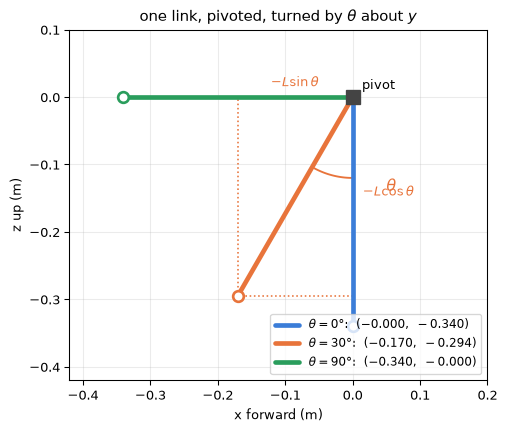

In [9]:
fig, ax = plt.subplots(figsize=(6.0, 4.6))
for deg, colour in zip((0, 30, 90), ("#3b7dd8", "#e8743b", "#2a9d5c")):
    t = np.radians(deg)
    x, z = -L * np.sin(t), -L * np.cos(t)
    ax.plot([0, x], [0, z], lw=3.5, color=colour, solid_capstyle="round", zorder=3,
            label=fr"$\theta={deg}°$:  $({x:+.3f},\ {z:+.3f})$")
    ax.plot(x, z, "o", ms=8, color="w", mec=colour, mew=2, zorder=4)
    if deg == 30:                                  # show where the two terms live
        ax.plot([x, x], [z, 0], ls=":", lw=1.2, color=colour)
        ax.plot([0, x], [z, z], ls=":", lw=1.2, color=colour)
        ax.annotate(r"$-L\sin\theta$", (x / 2, 0.015), color=colour, fontsize=10, ha="center")
        ax.annotate(r"$-L\cos\theta$", (0.015, z / 2), color=colour, fontsize=10)

arc = np.linspace(-np.pi / 2, -np.pi / 2 - np.radians(30), 40)
ax.plot(0.12 * np.cos(arc), 0.12 * np.sin(arc), color="#e8743b", lw=1.4)
ax.annotate(r"$\theta$", (0.05, -0.14), color="#e8743b", fontsize=12)
ax.plot(0, 0, "s", ms=10, color="#444", zorder=5)
ax.annotate("pivot", (0, 0), textcoords="offset points", xytext=(7, 6), fontsize=10)
ax.set_xlim(-0.42, 0.20); ax.set_ylim(-0.42, 0.10); ax.set_aspect("equal")
ax.set_xlabel("x forward (m)"); ax.set_ylabel("z up (m)")
ax.set_title(r"one link, pivoted, turned by $\theta$ about $y$", fontsize=11)
ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

Read the signs off the picture. At $0°$ the tip hangs directly below. At
$90°$ it has swung to horizontal at $x = -0.34$ — **backwards**. So a
*positive* pitch angle swings the leg **back**, which is why the Week 4
crouch commands a hip pitch of $-0.35$: negative means knee forward.

------------------------------------------------------------------------

## A transform is a rotation and a translation

To move a point from a child frame $b$ into its parent frame $a$, do two
things — turn it, then shift it:

$${\color{#c0392b}{\mathbf{p}_a}} = \underbrace{{\color{#e8743b}{R_{ab}}}\,{\color{#c0392b}{\mathbf{p}_b}}}_{\text{turn}} + \underbrace{{\color{#2a9d5c}{\mathbf{t}_{ab}}}}_{\text{shift}}$$

- ${\color{#c0392b}{\mathbf{p}_b}}$ — the point, in the child’s own
  coordinates (for a link: fixed forever, it is bolted on)
- ${\color{#e8743b}{R_{ab}}}$ — how the child is turned relative to the
  parent; its columns are the child’s axes written in the parent
- ${\color{#2a9d5c}{\mathbf{t}_{ab}}}$ — where the child’s **origin**
  sits, in the parent’s coordinates
- ${\color{#c0392b}{\mathbf{p}_a}}$ — the same physical point, now in
  the parent’s coordinates

**Why turn first, then shift?** ${\color{#c0392b}{\mathbf{p}_b}}$ is
measured along the child’s axes. ${\color{#e8743b}{R_{ab}}}$
re-expresses that arrow along the parent’s axes — same length, same
physical direction, new numbers. It is still an arrow *from the child’s
origin*, so adding ${\color{#2a9d5c}{\mathbf{t}_{ab}}}$ (parent origin →
child origin) makes it an arrow from the parent’s origin. Shift first
and you would be turning the offset as well, which is a different point.

A robot leg is this rule, once per link. The next slide chains two.

------------------------------------------------------------------------

## Chaining two transforms, step by step

Three frames: $a$ (say the pelvis), $b$ (the thigh), $c$ (the shin). We
know $b$ in $a$ and $c$ in $b$. We want $c$ in $a$ directly.

**Step 1 — from $c$ into $b$:**
$\;{\color{#c0392b}{\mathbf{p}_b}} = {\color{#e8743b}{R_{bc}}}{\color{#c0392b}{\mathbf{p}_c}} + {\color{#2a9d5c}{\mathbf{t}_{bc}}}$

**Step 2 — from $b$ into $a$:**
$\;{\color{#c0392b}{\mathbf{p}_a}} = {\color{#e8743b}{R_{ab}}}{\color{#c0392b}{\mathbf{p}_b}} + {\color{#2a9d5c}{\mathbf{t}_{ab}}}$

**Step 3 — substitute step 1 into step 2:**
$\;{\color{#c0392b}{\mathbf{p}_a}} = {\color{#e8743b}{R_{ab}}}\big({\color{#e8743b}{R_{bc}}}{\color{#c0392b}{\mathbf{p}_c}} + {\color{#2a9d5c}{\mathbf{t}_{bc}}}\big) + {\color{#2a9d5c}{\mathbf{t}_{ab}}}$

**Step 4 — multiply out, and group into “turn” and “shift”:**

$${\color{#c0392b}{\mathbf{p}_a}} = \underbrace{\big({\color{#e8743b}{R_{ab}R_{bc}}}\big)}_{{\color{#e8743b}{R_{ac}}}}{\color{#c0392b}{\mathbf{p}_c}} \;+\; \underbrace{\big({\color{#e8743b}{R_{ab}}}{\color{#2a9d5c}{\mathbf{t}_{bc}}} + {\color{#2a9d5c}{\mathbf{t}_{ab}}}\big)}_{{\color{#2a9d5c}{\mathbf{t}_{ac}}}}$$

So one transform $a \leftarrow c$ has
${\color{#e8743b}{R_{ac} = R_{ab}R_{bc}}}$ and
${\color{#2a9d5c}{\mathbf{t}_{ac}}} = {\color{#e8743b}{R_{ab}}}{\color{#2a9d5c}{\mathbf{t}_{bc}}} + {\color{#2a9d5c}{\mathbf{t}_{ab}}}$.

That is the whole of forward kinematics; the rest of today is applying
it six times. Note where ${\color{#e8743b}{R_{ab}}}$ sits in the
translation: **the parent’s rotation acts on the child’s offset** —
${\color{#2a9d5c}{\mathbf{t}_{bc}}}$ was measured along the thigh’s axes
and must be turned into the pelvis’s before it can be added. Forget that
and the leg swings from the wrong place.

------------------------------------------------------------------------

## Chaining two transforms, drawn

two steps     : p_a = [1.62   1.3858]
one transform : p_a = [1.62   1.3858]
t_ac = R_ab t_bc + t_ab = [0.7794 0.45  ] + [1.  0.4] = [1.7794 0.85  ]

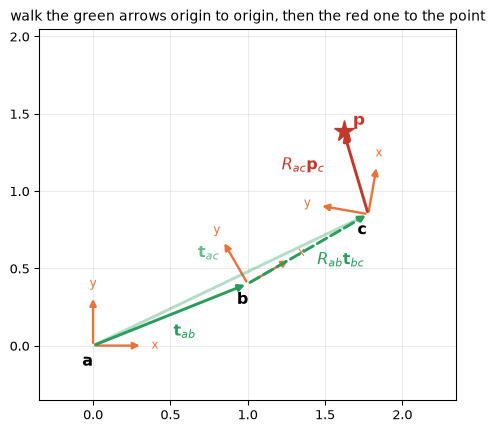

In [10]:
def R2d(deg):
    t = np.radians(deg)
    return np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])

R_ab, t_ab = R2d(30), np.array([1.0, 0.4])     # frame b, seen from a
R_bc, t_bc = R2d(50), np.array([0.9, 0.0])     # frame c, seen from b
p_c = np.array([0.5, 0.25])                    # a point bolted to c

p_b = R_bc @ p_c + t_bc                        # step 1
p_a = R_ab @ p_b + t_ab                        # step 2
R_ac, t_ac = R_ab @ R_bc, R_ab @ t_bc + t_ab   # step 4: one combined transform
print(f"two steps     : p_a = {np.round(p_a, 4)}")
print(f"one transform : p_a = {np.round(R_ac @ p_c + t_ac, 4)}")
print(f"t_ac = R_ab t_bc + t_ab = {np.round(R_ab @ t_bc, 4)} + {t_ab} = {np.round(t_ac, 4)}")

fig, ax = plt.subplots(figsize=(7.4, 4.6))
def triad(o, R, name):
    for k, lab in ((0, "x"), (1, "y")):
        ax.annotate("", xy=o + 0.32 * R[:, k], xytext=o,
                    arrowprops=dict(arrowstyle="-|>", color="#e8743b", lw=1.8))
        ax.text(*(o + 0.40 * R[:, k]), lab, color="#e8743b", fontsize=9, ha="center", va="center")
    ax.text(*(o + np.array([-0.07, -0.13])), name, fontsize=12, weight="bold")

triad(np.zeros(2), np.eye(2), "a")
triad(t_ab, R_ab, "b")
triad(t_ac, R_ac, "c")
arrow = dict(arrowstyle="-|>", lw=2.2)
ax.annotate("", xy=t_ab, xytext=(0, 0), arrowprops={**arrow, "color": "#2a9d5c"})
ax.text(*(t_ab / 2 + [0.02, -0.14]), r"$\mathbf{t}_{ab}$", color="#2a9d5c", fontsize=12)
ax.annotate("", xy=t_ac, xytext=t_ab, arrowprops={**arrow, "color": "#2a9d5c", "ls": "--"})
ax.text(*((t_ab + t_ac) / 2 + [0.06, -0.10]), r"$R_{ab}\mathbf{t}_{bc}$", color="#2a9d5c", fontsize=12)
ax.annotate("", xy=t_ac, xytext=(0, 0), arrowprops={**arrow, "color": "#2a9d5c", "alpha": 0.35})
ax.text(*(t_ac * 0.55 + [-0.30, 0.10]), r"$\mathbf{t}_{ac}$", color="#2a9d5c", fontsize=12, alpha=0.7)
ax.annotate("", xy=p_a, xytext=t_ac, arrowprops={**arrow, "color": "#c0392b"})
ax.text(*((t_ac + p_a) / 2 + [-0.48, 0.02]), r"$R_{ac}\mathbf{p}_c$", color="#c0392b", fontsize=12)
ax.plot(*p_a, "*", ms=16, color="#c0392b", zorder=5)
ax.text(*(p_a + [0.06, 0.04]), r"$\mathbf{p}$", color="#c0392b", fontsize=13)
ax.set_xlim(-0.35, 2.35); ax.set_ylim(-0.35, 2.05); ax.set_aspect("equal"); ax.grid(alpha=0.25)
ax.set_title("walk the green arrows origin to origin, then the red one to the point", fontsize=10.5)
fig.tight_layout(); plt.show()

The dashed green arrow is
${\color{#2a9d5c}{\mathbf{t}_{bc}}} = (0.9, 0)$ — straight along $b$’s
own $x$ axis — drawn in $a$, where it is tilted $30°$ because $b$ is.
That tilt is the ${\color{#e8743b}{R_{ab}}}$ in front of it.

------------------------------------------------------------------------

## One matrix instead of two rules: homogeneous transforms

Two rules (multiply the rotations; turn-and-add the translations) are
easy to get wrong. Pack both into one $4\times4$ matrix and let matrix
multiplication do the bookkeeping. Append a $1$ to the point:

$${\color{#8e44ad}{T_{ab}}} = \begin{bmatrix} {\color{#e8743b}{R_{ab}}} & {\color{#2a9d5c}{\mathbf{t}_{ab}}}\\ \mathbf{0}^{\top} & 1\end{bmatrix},
\qquad
\tilde{\mathbf{p}} = \begin{bmatrix}{\color{#c0392b}{\mathbf{p}}}\\ 1\end{bmatrix}$$

**Step 1 — it applies the rule.** Multiply block by block:
${\color{#8e44ad}{T_{ab}}}\tilde{\mathbf{p}}_b = \begin{bmatrix}{\color{#e8743b}{R_{ab}}}{\color{#c0392b}{\mathbf{p}_b}} + {\color{#2a9d5c}{\mathbf{t}_{ab}}}\cdot 1\\ 0 + 1\end{bmatrix}$.
The appended $1$ is what picks up the translation; the bottom row keeps
it a $1$.

**Step 2 — it chains by plain multiplication.**
${\color{#8e44ad}{T_{ab}T_{bc}}} = \begin{bmatrix}{\color{#e8743b}{R_{ab}R_{bc}}} & {\color{#e8743b}{R_{ab}}}{\color{#2a9d5c}{\mathbf{t}_{bc}}} + {\color{#2a9d5c}{\mathbf{t}_{ab}}}\\ \mathbf{0}^{\top} & 1\end{bmatrix}$
— exactly step 4 of the chaining slide, now automatic. A leg is
${\color{#8e44ad}{T_{\text{pelvis}\leftarrow\text{foot}} = T_1T_2\cdots T_6}}$.

A **direction** (an axis, a velocity) gets a $0$ appended instead of a
$1$: it then turns with ${\color{#e8743b}{R}}$ but ignores
${\color{#2a9d5c}{\mathbf{t}}}$ — an arrow has no position to shift.

------------------------------------------------------------------------

## Undoing a transform, checked on the robot

**Step 3 — it undoes cleanly.** Solve
${\color{#c0392b}{\mathbf{p}_a}} = {\color{#e8743b}{R}}{\color{#c0392b}{\mathbf{p}_b}} + {\color{#2a9d5c}{\mathbf{t}}}$
for ${\color{#c0392b}{\mathbf{p}_b}}$: subtract
${\color{#2a9d5c}{\mathbf{t}}}$, then multiply by
${\color{#e8743b}{R}}^{-1} = {\color{#e8743b}{R}}^{\top}$ (a rotation’s
inverse is its transpose, because its columns are perpendicular unit
vectors):

$${\color{#c0392b}{\mathbf{p}_b}} = {\color{#e8743b}{R}}^{\top}\big({\color{#c0392b}{\mathbf{p}_a}} - {\color{#2a9d5c}{\mathbf{t}}}\big)
\qquad\Longrightarrow\qquad
{\color{#8e44ad}{T}}^{-1} = \begin{bmatrix}{\color{#e8743b}{R}}^{\top} & -{\color{#e8743b}{R}}^{\top}{\color{#2a9d5c}{\mathbf{t}}}\\ \mathbf{0}^{\top} & 1\end{bmatrix}$$

That is the `pelvis_rot.T @ (foot_world - pelvis_pos)` of the
three-frames slide. The pelvis’s pose is `qpos[:3]` (its
${\color{#2a9d5c}{\mathbf{t}}}$) and `qpos[3:7]` (a quaternion for its
${\color{#e8743b}{R}}$):

In [11]:
def make_T(R, t):
    """4x4 homogeneous transform from a 3x3 rotation and a 3-vector translation."""
    T = np.eye(4)
    T[:3, :3], T[:3, 3] = R, t
    return T

def inv_T(T):
    """The closed-form inverse from step 3: [R^T, -R^T t; 0, 1]."""
    R, t = T[:3, :3], T[:3, 3]
    return make_T(R.T, -R.T @ t)

T_wp = make_T(pelvis_rot, pelvis_pos)             # pelvis, seen from the world
foot_h = np.r_[foot_world, 1.0]                    # append the 1

print("T_world<-pelvis =", np.round(T_wp, 4).tolist())
print("foot in the pelvis frame, via inv_T :", np.round((inv_T(T_wp) @ foot_h)[:3], 4))
print("the same, as the three-frames slide  :", np.round(pelvis_rot.T @ (foot_world - pelvis_pos), 4))
print(f"inv_T(T) @ T == identity, to          {np.abs(inv_T(T_wp) @ T_wp - np.eye(4)).max():.1e}")
print(f"closed form vs np.linalg.inv          {np.abs(inv_T(T_wp) - np.linalg.inv(T_wp)).max():.1e}")

T_world<-pelvis = [[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.79], [0.0, 0.0, 0.0, 1.0]]
foot in the pelvis frame, via inv_T : [-0.      0.1185 -0.7569]
the same, as the three-frames slide  : [-0.      0.1185 -0.7569]
inv_T(T) @ T == identity, to          0.0e+00
closed form vs np.linalg.inv          0.0e+00

At `stand` the pelvis is upright, so its ${\color{#e8743b}{R}}$ is the
identity and ${\color{#2a9d5c}{\mathbf{t}}}$ is its height, $0.79$ m —
the last entry of the third row. The closed-form inverse needs one
transpose and no general matrix inversion, and agrees with NumPy’s.

------------------------------------------------------------------------

## Order in a chain, drawn: parent first

${\color{#8e44ad}{T_{ab}T_{bc}}}$ and ${\color{#8e44ad}{T_{bc}T_{ab}}}$
are different robots. A planar leg built twice — hip $-0.35$, knee
$+0.70$ rad, links 0.34 and 0.30 m (rounded, for the sketch); each joint
is “turn by ${\color{#3b7dd8}{\theta}}$, then step $L$ down the link”:

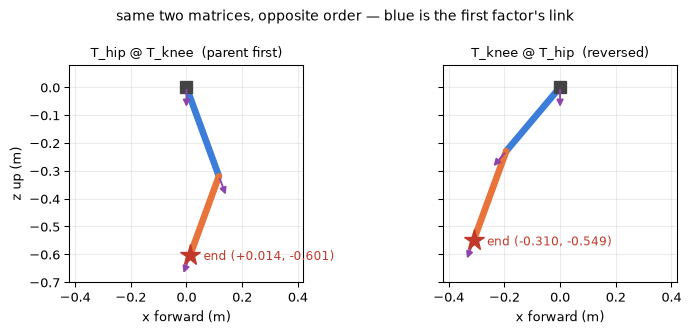

In [12]:
def T_link(theta, L):
    """Planar (x, z) link, pivot convention of the pendulum slide: turn, then step -L."""
    c, s = np.cos(theta), np.sin(theta)
    turn = np.array([[c, s, 0], [-s, c, 0], [0, 0, 1]])   # R_y restricted to (x, z)
    step = np.array([[1, 0, 0], [0, 1, -L], [0, 0, 1]])
    return turn @ step

T_hip, T_knee = T_link(-0.35, 0.34), T_link(0.70, 0.30)
origin = np.array([0.0, 0.0, 1.0])
chains = {"T_hip @ T_knee  (parent first)": [np.eye(3), T_hip, T_hip @ T_knee],
          "T_knee @ T_hip  (reversed)":     [np.eye(3), T_knee, T_knee @ T_hip]}

fig, axs = plt.subplots(1, 2, figsize=(8.4, 3.5), sharey=True)
for ax, (title, Ts) in zip(axs, chains.items()):
    pts = np.array([T @ origin for T in Ts])[:, :2]
    ax.plot(pts[:2, 0], pts[:2, 1], lw=5, color="#3b7dd8", solid_capstyle="round")
    ax.plot(pts[1:, 0], pts[1:, 1], lw=5, color="#e8743b", solid_capstyle="round")
    for T in Ts:                                       # each frame's own "down the link"
        o, d = (T @ origin)[:2], (T @ [0, -0.08, 0])[:2]
        ax.annotate("", xy=o + d, xytext=o,
                    arrowprops=dict(arrowstyle="-|>", color="#8e44ad", lw=1.4))
    ax.plot(*pts[-1], "*", ms=16, color="#c0392b", zorder=5)
    ax.annotate(f"end ({pts[-1, 0]:+.3f}, {pts[-1, 1]:+.3f})", pts[-1],
                textcoords="offset points", xytext=(10, -4), fontsize=9, color="#c0392b")
    ax.plot(0, 0, "s", ms=9, color="#444")
    ax.set_title(title, fontsize=10); ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.set_xlim(-0.42, 0.42); ax.set_ylim(-0.70, 0.08); ax.set_xlabel("x forward (m)")
axs[0].set_ylabel("z up (m)")
fig.suptitle("same two matrices, opposite order — blue is the first factor's link", fontsize=10.5)
fig.tight_layout(); plt.show()

Read a product **left to right, root to tip**: each factor acts in the
frame its left-hand neighbours produced. Left: the knee turns about a
knee the hip already carried. Right: the “hip” link hangs off a shin —
another machine; the foot ends 32 cm further back and 5 cm higher. So
`my_fk` writes `rot = rot @ Rj`: the joint goes on the **right**,
turning about the link’s own, already-moved axis.

------------------------------------------------------------------------

## Order matters, and you can feel it

Put a book flat on the desk, cover up. Then:

1.  Turn it $90°$ about the **vertical** axis, then tip it $90°$
    **toward you**
2.  Start over. Tip it $90°$ **toward you** first, then turn $90°$ about
    vertical

The book ends in two different orientations. This is not an illusion:

In [13]:
def Rx(t): return np.array([[1, 0, 0], [0, np.cos(t), -np.sin(t)], [0, np.sin(t), np.cos(t)]])
def Rz(t): return np.array([[np.cos(t), -np.sin(t), 0], [np.sin(t), np.cos(t), 0], [0, 0, 1]])

p, h = np.array([1.0, 0.0, 0.0]), np.pi / 2
print(f"  start with the point       {p}")
print(f"  about z, then x        ->  {np.round(Rx(h) @ Rz(h) @ p, 3)}")
print(f"  about x, then z        ->  {np.round(Rz(h) @ Rx(h) @ p, 3)}")
print(f"  the answers are {np.linalg.norm(Rx(h) @ Rz(h) @ p - Rz(h) @ Rx(h) @ p):.3f} apart")

  start with the point       [1. 0. 0.]
  about z, then x        ->  [0. 0. 1.]
  about x, then z        ->  [0. 1. 0.]
  the answers are 1.414 apart

Same point, same two rotations, **a different axis entirely**. Matrix
multiplication does not commute, and neither does turning things in
space.

------------------------------------------------------------------------

## The book, both ways

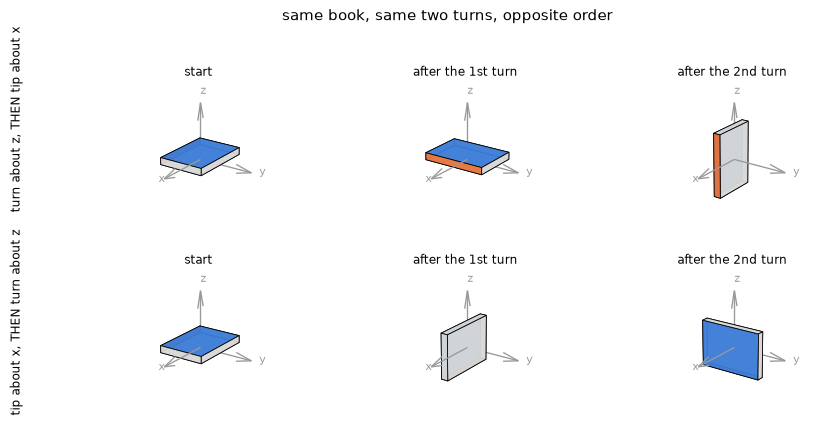

In [14]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def book(R):
    """Corners of a book-shaped box, turned by R. Cover blue, spine orange."""
    w, d, t = 0.9, 0.65, 0.1
    c = np.array([[x, y, z] for x in (-w/2, w/2) for y in (-d/2, d/2) for z in (0, t)]) @ R.T
    faces = [[0, 1, 3, 2], [4, 5, 7, 6], [0, 1, 5, 4], [2, 3, 7, 6], [0, 2, 6, 4], [1, 3, 7, 5]]
    colours = ["#d9d9d9", "#d9d9d9", "#e8743b", "#d9d9d9", "#d9d9d9", "#3b7dd8"]
    return [c[f] for f in faces], colours

fig = plt.figure(figsize=(9.4, 4.6))
rows = [("turn about z, THEN tip about x", [np.eye(3), Rz(h), Rx(h) @ Rz(h)]),
        ("tip about x, THEN turn about z", [np.eye(3), Rx(h), Rz(h) @ Rx(h)])]
for r, (label, mats) in enumerate(rows):
    for c_, R in enumerate(mats):
        ax = fig.add_subplot(2, 3, r * 3 + c_ + 1, projection="3d")
        faces, colours = book(R)
        ax.add_collection3d(Poly3DCollection(faces, facecolors=colours,
                                             edgecolors="k", linewidths=0.6, alpha=0.95))
        for vec, name in [((0.8, 0, 0), "x"), ((0, 0.8, 0), "y"), ((0, 0, 0.8), "z")]:
            ax.quiver(0, 0, 0, *vec, color="#999", lw=1)
            ax.text(*np.array(vec) * 1.15, name, color="#999", fontsize=8)
        for lim in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
            lim(-0.62, 0.62)
        ax.set_box_aspect((1, 1, 1)); ax.set_axis_off(); ax.view_init(elev=22, azim=35)
        ax.set_title(["start", "after the 1st turn", "after the 2nd turn"][c_], fontsize=9)
    fig.text(0.015, 0.73 - r * 0.46, label, rotation=90, va="center", fontsize=9)
fig.suptitle("same book, same two turns, opposite order", fontsize=11)
fig.tight_layout(rect=(0.04, 0, 1, 0.95)); plt.show()

Follow the **blue cover** and the **orange spine**. Both rows start
identically and end differently.

**Consequence:** “roll 10°, pitch 20°, yaw 5°” is meaningless until you
say in which order. That is why we compose matrices down the chain
instead.

------------------------------------------------------------------------

## Two links on paper: the leg you are about to code

Chain the 2D result twice. Hip at height $z_h$, thigh $L_1$, shin $L_2$,
hip angle $\theta_1$, knee angle $\theta_2$:

$$\text{knee} = \big(-L_1\sin\theta_1,\;\; z_h - L_1\cos\theta_1\big)$$
$$\text{ankle} = \big(\text{knee}_x - L_2\sin(\theta_1{+}\theta_2),\;\; \text{knee}_z - L_2\cos(\theta_1{+}\theta_2)\big)$$

The angles **add**, because the knee angle is measured relative to the
thigh and the thigh has already turned by $\theta_1$.

Now measure $L_1$ and $L_2$ from the real robot — **between joint
anchors**, not from any single body offset:

In [15]:
def anchor(d, body_name):
    """World position of a body's joint axis — the point the link pivots about."""
    b = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body_name)
    return d.xpos[b] + d.xmat[b].reshape(3, 3) @ model.jnt_pos[model.body_jntadr[b]]

H = anchor(data, "left_hip_pitch_link")
K = anchor(data, "left_knee_link")
A = anchor(data, "left_ankle_pitch_link")
foot_drop = np.linalg.norm(data.site_xpos[kin.foot_site_id(model, "left")] - A)

L1 = np.hypot(*(K - H)[[0, 2]])
L2 = np.hypot(*(A - K)[[0, 2]])
print(f"  hip -> knee   : {np.round(K - H, 4)}   "
      f"true length {np.linalg.norm(K - H):.4f} m,  in-plane L1 = {L1:.4f} m")
print(f"  knee -> ankle : {np.round(A - K, 4)}   "
      f"true length {np.linalg.norm(A - K):.4f} m,  in-plane L2 = {L2:.4f} m")
print(f"  ankle -> foot site : {foot_drop:.4f} m   (the site is NOT the sole -- see below)")

  hip -> knee   : [-0.      0.0541 -0.3366]   true length 0.3409 m,  in-plane L1 = 0.3366 m
  knee -> ankle : [ 0.e+00 -1.e-04 -3.e-01]   true length 0.3000 m,  in-plane L2 = 0.3000 m
  ankle -> foot site : 0.0176 m   (the site is NOT the sole -- see below)

Look at the thigh: it is **not** straight down. It splays 5.4 cm
sideways, so its true length 0.3409 m is not the number a flat picture
needs — 0.3366 m is.

------------------------------------------------------------------------

## The leg, as the formula sees it

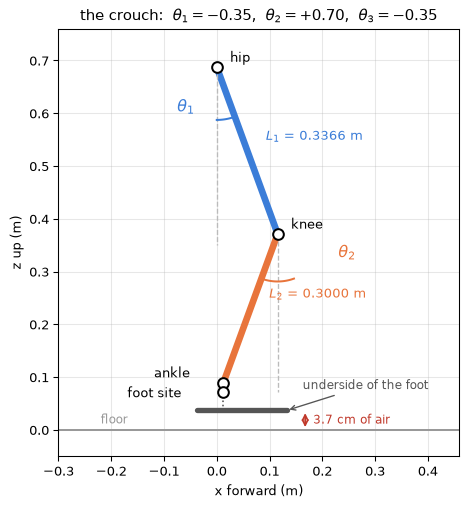

In [16]:
th1, th2, th3 = crouch[0], crouch[3], crouch[4]
kx, kz = H[0] - L1 * np.sin(th1), H[2] - L1 * np.cos(th1)
ax_, az = kx - L2 * np.sin(th1 + th2), kz - L2 * np.cos(th1 + th2)
fx, fz = ax_ - foot_drop * np.sin(th1+th2+th3), az - foot_drop * np.cos(th1+th2+th3)

fig, ax = plt.subplots(figsize=(6.0, 5.4))
ax.plot([H[0], kx], [H[2], kz], lw=5, color="#3b7dd8", solid_capstyle="round", zorder=2)
ax.plot([kx, ax_], [kz, az], lw=5, color="#e8743b", solid_capstyle="round", zorder=2)
ax.plot([ax_, fx], [az, fz], lw=5, color="#555", solid_capstyle="round", zorder=2)
ax.plot([H[0], H[0]], [H[2], H[2] - L1], ls="--", lw=1, color="#bbb")   # "straight down"
ax.plot([kx, kx], [kz, kz - L2], ls="--", lw=1, color="#bbb")

for (px, pz), lab, off in [((H[0], H[2]), "hip", (10, 4)), ((kx, kz), "knee", (10, 4)),
                           ((ax_, az), "ankle", (-52, 4)), ((fx, fz), "foot site", (-72, -4))]:
    ax.plot(px, pz, "o", ms=8, color="w", mec="k", mew=1.5, zorder=3)
    ax.annotate(lab, (px, pz), textcoords="offset points", xytext=off, fontsize=10)

# the foot site is NOT the sole: draw the real foot under it, measured from the model
foot_sid = kin.foot_site_id(model, "left")
pads = [g for g in range(model.ngeom)
        if model.geom_bodyid[g] == model.site_bodyid[foot_sid] and model.geom_group[g] == 3]
rel = np.array([data.geom_xpos[g] - data.site_xpos[foot_sid] for g in pads])
heel, toe = rel[:, 0].min(), rel[:, 0].max()
under = rel[:, 2].min() - model.geom_size[pads[0]][0]

ax.plot([fx + heel, fx + toe], [fz + under, fz + under], lw=4, color="#555",
        solid_capstyle="round", zorder=2)
ax.plot([fx, fx], [fz, fz + under], lw=1.2, ls=":", color="#555")
ax.annotate("underside of the foot", (fx + toe, fz + under), textcoords="offset points",
            xytext=(12, 16), fontsize=9, color="#555",
            arrowprops=dict(arrowstyle="->", color="#555", lw=1))
ax.annotate("", xy=(fx + toe + 0.035, 0), xytext=(fx + toe + 0.035, fz + under),
            arrowprops=dict(arrowstyle="<->", color="#c0392b", lw=1.3))
ax.annotate(f"{(fz + under) * 100:.1f} cm of air", (fx + toe + 0.05, (fz + under) / 2),
            fontsize=9, color="#c0392b", va="center")

ax.annotate(f"$L_1$ = {L1:.4f} m", ((H[0] + kx) / 2, (H[2] + kz) / 2),
            textcoords="offset points", xytext=(14, 8), fontsize=10, color="#3b7dd8")
ax.annotate(f"$L_2$ = {L2:.4f} m", ((kx + ax_) / 2, (kz + az) / 2),
            textcoords="offset points", xytext=(14, 8), fontsize=10, color="#e8743b")

arc = np.linspace(-np.pi/2, -np.pi/2 - th1, 40)
ax.plot(H[0] + 0.10*np.cos(arc), H[2] + 0.10*np.sin(arc), color="#3b7dd8", lw=1.5)
ax.annotate(r"$\theta_1$", (H[0] - 0.075, H[2] - 0.085), color="#3b7dd8", fontsize=12)
arc = np.linspace(-np.pi/2 - th1, -np.pi/2 - th1 - th2, 40)
ax.plot(kx + 0.09*np.cos(arc), kz + 0.09*np.sin(arc), color="#e8743b", lw=1.5)
ax.annotate(r"$\theta_2$", (kx + 0.115, kz - 0.045), color="#e8743b", fontsize=12)

ax.axhline(0, color="#999", lw=1.5)
ax.text(-0.22, 0.012, "floor", color="#999", fontsize=9)
ax.set_xlim(-0.30, 0.46); ax.set_ylim(-0.05, 0.76); ax.set_aspect("equal")
ax.set_xlabel("x forward (m)"); ax.set_ylabel("z up (m)")
ax.set_title(r"the crouch:  $\theta_1 = -0.35$,  $\theta_2 = +0.70$,  $\theta_3 = -0.35$",
             fontsize=11)
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

Each dashed line is where the link **would** point at zero angle, so
each arc is literally the joint’s angle. The knee angle is measured
**from the thigh**, not from vertical — which is why the two add in the
formula.

------------------------------------------------------------------------

## Two things that figure is telling you

**The site we call “the foot” is not the bottom of the foot.**
`left_foot` is a site at the ankle-roll link’s *origin*, 3.5 cm above
the four contact spheres. Forward kinematics reports where that *frame*
is; touching the ground is a separate question.

**And the foot is in the air.** The pelvis is pinned at standing height
while the leg bends, so the foot rises 3.7 cm off the floor. That is not
an error in the drawing — it is the point made three slides in:
**kinematics places a pose; it does not settle a robot onto the
ground.** A real crouch lowers the pelvis instead, which is exactly what
the Week 4 walker does.

Two details worth noticing while you are here:

- The pitch angles sum to zero ($-0.35 + 0.70 - 0.35$), so the **foot
  stays level**. That is deliberate: a foot that lands tilted trips.
- The foot runs from $-0.05$ m (heel) to $+0.12$ m (toe) about the
  ankle. It is longer in front, which is why $+x$ is forward.

------------------------------------------------------------------------

## Does the paper answer match the simulator?

Three angles in, one foot position out — pure arithmetic, no physics:

In [17]:
def paper_fk(th1, th2, th3):
    """Foot (x, z) from hip, knee and ankle pitch angles. Nothing but sin and cos."""
    kx, kz = H[0] - L1 * np.sin(th1),     H[2] - L1 * np.cos(th1)
    ax, az = kx - L2 * np.sin(th1 + th2), kz - L2 * np.cos(th1 + th2)
    return np.array([ax - foot_drop * np.sin(th1 + th2 + th3),
                     az - foot_drop * np.cos(th1 + th2 + th3)])

def xz(v):
    return f"({v[0]:+.6f}, {v[1]:+.6f})"

print(f"{'hip, knee, ankle':>21}  {'paper (x, z)':>22}  {'mujoco (x, z)':>22}   error")
for angles in [(0, 0, 0), (-0.35, 0.70, -0.35), (-0.4, 0.9, -0.5), (0.3, 0.2, -0.1)]:
    th1, th2, th3 = angles
    d = soc4180.keyframe_data(model, "stand")
    d.qpos[idx] = [th1, 0, 0, th2, th3, 0]          # roll and yaw held at zero
    mujoco.mj_forward(model, d)
    mine = paper_fk(th1, th2, th3)
    theirs = d.site_xpos[kin.foot_site_id(model, "left")][[0, 2]]
    print(f"{str(angles):>21}  {xz(mine):>22}  {xz(theirs):>22}   "
          f"{np.abs(mine - theirs).max():.1e}")

     hip, knee, ankle            paper (x, z)           mujoco (x, z)   error
            (0, 0, 0)  (+0.000000, +0.033136)  (-0.000002, +0.033136)   2.3e-06
  (-0.35, 0.7, -0.35)  (+0.012545, +0.071732)  (+0.012543, +0.071731)   2.2e-06
    (-0.4, 0.9, -0.5)  (-0.012756, +0.096433)  (-0.012758, +0.096432)   2.1e-06
     (0.3, 0.2, -0.1)  (-0.250141, +0.086282)  (-0.250143, +0.086283)   2.2e-06

**Two micrometres.** Your `sin` and `cos` predict a 29-degree-of-freedom
simulator to about the width of a bacterium.

Not *zero*, though, and the gap is honest: the flat two-link picture is
a **model** of the leg. At the zero pose MuJoCo puts the foot
$2.3\,\mu$m *behind* the hip rather than exactly beneath it, because the
G1’s own offsets do not quite cancel. Later in this lab we compose the
real chain and the error drops to $10^{-16}$.

------------------------------------------------------------------------

## What the two-link picture leaves out

It reached micrometres, so why not stop there? Because we cheated three
times:

- **We held hip roll, hip yaw and ankle roll at zero.** Switch any of
  them on and the foot leaves the $xz$ plane, and flat trigonometry has
  nowhere to put it.
- **We computed a position, not a pose.** A foot also has an
  *orientation* — it has to land flat — and that is three more numbers.
- **We derived it for this leg.** Change the robot and you redo the
  algebra by hand.

**Six joints, six freedoms** — three of position, three of orientation.
That match is not an accident of design: it is the minimum needed to put
a foot *anywhere*, *any way up*. It is also why next week’s inverse
problem is solvable at all.

So we need a method that handles all six, needs no algebra, and works
for any robot. That method is: compose the transforms, one body at a
time.

------------------------------------------------------------------------

## Ways to write a rotation

**First, why bother?** Only the matrix multiplies a vector. So if the
matrix does all the work, why does anyone use the other three?

**Because a rotation is three numbers’ worth of information, and the
matrix spends nine.** The other three forms are compressions of it:

| Representation | Numbers | Constraints | Freedoms | Good at | Bad at |
|------------|------------|------------|------------|------------|------------|
| Rotation matrix | 9 | 6 | 3 | acting on a vector; composing | storing — 6 rules to keep true |
| **Quaternion** | 4 | 1 | 3 | **storing**; interpolating | reading; sign ambiguity |
| Axis–angle | 3 | 0 | 3 | **angular velocity and error** | composing |
| Euler angles | 3 | 0 | 3 | **saying out loud** | gimbal lock; a dozen conventions |

Count the constraints, not just the numbers. A matrix you keep
multiplying drifts off the set of valid rotations and must be
**re-orthonormalised** — six rules to restore. A quaternion needs only
`q /= norm(q)`. That is why MuJoCo’s `qpos` stores the floating base as
**4 numbers, not 9**.

------------------------------------------------------------------------

## Which way does the traffic flow?

**Today, one way only.** Every representation gets converted *into* $R$,
and never back:

$$\text{axis-angle},\ \text{quaternion},\ \text{Euler} \;\longrightarrow\; R \;\longrightarrow\; \mathbf{v}' = R\mathbf{v}$$

`my_fk` is the proof: it reads `body_quat` and a joint axis-angle, turns
both into matrices, and from then on only multiplies. Nothing ever asks
“what quaternion is this matrix?”

**Next week, the traffic reverses** — and it is worth knowing now, so
the rule does not become a superstition. Inverse kinematics needs an
orientation *error*, and the Jacobian’s angular rows expect a
**3-vector**, not a 3×3. So `soc4180.kinematics.pose_error` runs the
other way:

Inside it: `residual = target_mat @ cur.T` is a 3×3 saying *how far the
foot is from its target*, then `mju_mat2Quat` and `mju_quat2Vel` walk it
back down to three numbers. Ask for a **2 cm** move and a **10°** turn,
and see what comes out:

In [18]:
d_err = soc4180.keyframe_data(model, "stand")
d_err.qpos[idx] = crouch
mujoco.mj_forward(model, d_err)

sid = kin.foot_site_id(model, "left")
cur = d_err.site_xmat[sid].reshape(3, 3)

turn = np.zeros(4)                                  # a 10 degree turn about y
mujoco.mju_axisAngle2Quat(turn, np.array([0.0, 1.0, 0.0]), np.radians(10))

err = kin.pose_error(d_err, sid,
                     d_err.site_xpos[sid] + np.array([0.02, 0.0, 0.0]),
                     quat2mat(turn) @ cur)

print("pose_error returns one 6-vector:", np.round(err, 4))
print("   position part :", np.round(err[:3], 4), " <- the 2 cm we asked for")
print("   rotation part :", np.round(err[3:], 4),
      f" <- {np.degrees(np.linalg.norm(err[3:])):.2f} deg about y")
print("   half of it    :", np.round(err[3:] / 2, 4), " <- and it can be halved")

pose_error returns one 6-vector: [0.02   0.     0.     0.     0.1745 0.    ]
   position part : [0.02 0.   0.  ]  <- the 2 cm we asked for
   rotation part : [0.     0.1745 0.    ]  <- 10.00 deg about y
   half of it    : [0.     0.0873 0.    ]  <- and it can be halved

There is the fourth reason for the compact forms, and the one that
actually bites: **an error has to be a vector you can scale and add.** A
3×3 matrix cannot be halved — half of a rotation matrix is not a
rotation. An axis-angle vector can, and halving it means exactly “go
half way there”, which is what every IK step does.

So: compress to **store**, expand to **act**, compress again to
**correct**.

------------------------------------------------------------------------

## One rotation, four ways

A table is abstract until you see one rotation written all four ways.
Turn by **120° about the diagonal axis $(1,1,1)/\sqrt{3}$** — the axis
pointing out of the corner of a cube. Watch what it does to the three
axes:

In [19]:
diag = np.ones(3) / np.sqrt(3)
q120 = np.zeros(4)
mujoco.mju_axisAngle2Quat(q120, diag, np.radians(120))
R120 = quat2mat(q120)

def tidy(a):
    """Round, and turn -0.0 into 0.0 so the numbers read cleanly."""
    a = np.round(a, 4)
    return np.where(a == 0, 0.0, a)

q_euler = np.zeros(4)
mujoco.mju_euler2Quat(q_euler, np.radians([90.0, 90.0, 0.0]), "xyz")

print("AXIS-ANGLE  : 120 deg about", tidy(diag), "   <- 3 numbers")
print("QUATERNION  :", tidy(q120), "                    <- 4 numbers (w, x, y, z)")
print("EULER       : roll 90, pitch 90, yaw 0, 'xyz'        <- 3 numbers")
print("              same rotation as the quaternion?", np.allclose(quat2mat(q_euler), R120))
print("\nMATRIX      :                                       <- 9 numbers")
for row in tidy(R120):
    print("             ", row)

print("\nwhat it does to the three axes:")
for name, v in [("x", [1, 0, 0]), ("y", [0, 1, 0]), ("z", [0, 0, 1])]:
    print(f"   {name} -> {tidy(R120 @ v)}")

AXIS-ANGLE  : 120 deg about [0.5774 0.5774 0.5774]    <- 3 numbers
QUATERNION  : [0.5 0.5 0.5 0.5]                     <- 4 numbers (w, x, y, z)
EULER       : roll 90, pitch 90, yaw 0, 'xyz'        <- 3 numbers
              same rotation as the quaternion? True

MATRIX      :                                       <- 9 numbers
              [0. 0. 1.]
              [1. 0. 0.]
              [0. 1. 0.]

what it does to the three axes:
   x -> [0. 1. 0.]
   y -> [0. 0. 1.]
   z -> [1. 0. 0.]

It sends $x \to y \to z \to x$ — a three-fold cycle, which is why $120°$
brings the cube corner back to itself. Every row above is the **same
rotation**, and each is the natural choice for a different job: the
quaternion to *store*, the matrix to *compose*, axis-angle to *reason
about*, Euler to *say out loud*.

**But “same rotation” was asserted, not shown.** The next three slides
do the conversions by hand — because the matrix is the one form that
actually acts on a vector, so every other form has to reach it.

------------------------------------------------------------------------

## Axis-angle $\to R$: Rodrigues, derived

Turn a vector $\mathbf{v}$ by ${\color{#3b7dd8}{\theta}}$ about a
**unit** axis $\mathbf{u}$. Five steps, each one a picture on the next
slide:

**Step 1 — split $\mathbf{v}$ into “along the axis” and “across it”.**
$\;\mathbf{v}_{\parallel} = (\mathbf{u}\cdot\mathbf{v})\,\mathbf{u}, \qquad \mathbf{v}_{\perp} = \mathbf{v} - \mathbf{v}_{\parallel}$

**Step 2 — the part along the axis does not move.** A spit-roast turns
the chicken, not the spit:
$\mathbf{v}_{\parallel}' = \mathbf{v}_{\parallel}$.

**Step 3 — the part across the axis turns in a flat plane.** That plane
has two perpendicular arrows of the same length: $\mathbf{v}_{\perp}$
and $\mathbf{w} = \mathbf{u}\times\mathbf{v}$ (a quarter-turn of
$\mathbf{v}_{\perp}$ about $\mathbf{u}$). A 2-D turn by
${\color{#3b7dd8}{\theta}}$ in that plane is
$\;\mathbf{v}_{\perp}' = \cos{\color{#3b7dd8}{\theta}}\;\mathbf{v}_{\perp} + \sin{\color{#3b7dd8}{\theta}}\;\mathbf{w}$
— the same $\cos$/$\sin$ mix as $R_z$, with $\mathbf{v}_{\perp}$ playing
$x$ and $\mathbf{w}$ playing $y$.

**Step 4 — add the pieces back:**
$\;\mathbf{v}' = \mathbf{v}_{\parallel} + \cos{\color{#3b7dd8}{\theta}}\,(\mathbf{v} - \mathbf{v}_{\parallel}) + \sin{\color{#3b7dd8}{\theta}}\;\mathbf{u}\times\mathbf{v}
= \cos{\color{#3b7dd8}{\theta}}\,\mathbf{v} + (1-\cos{\color{#3b7dd8}{\theta}})(\mathbf{u}\cdot\mathbf{v})\,\mathbf{u} + \sin{\color{#3b7dd8}{\theta}}\;\mathbf{u}\times\mathbf{v}$

**Step 5 — write each term as a matrix times $\mathbf{v}$.**
$(\mathbf{u}\cdot\mathbf{v})\,\mathbf{u} = \mathbf{u}\mathbf{u}^{\top}\mathbf{v}$,
and $\mathbf{u}\times\mathbf{v} = [\mathbf{u}]_{\times}\mathbf{v}$ with
the cross-product matrix below. Pull out the $\mathbf{v}$:

$${\color{#e8743b}{R}} = I\cos{\color{#3b7dd8}{\theta}} \;+\; (1-\cos{\color{#3b7dd8}{\theta}})\,\mathbf{u}\mathbf{u}^{\top} \;+\; [\mathbf{u}]_{\times}\sin{\color{#3b7dd8}{\theta}},
\qquad
[\mathbf{u}]_{\times} = \begin{bmatrix} 0 & -u_z & u_y \\ u_z & 0 & -u_x \\ -u_y & u_x & 0\end{bmatrix}$$

(Multiply $[\mathbf{u}]_{\times}$ by $\mathbf{v}$ by hand once: the rows
come out as $u_y v_z - u_z v_y$, and so on — the cross product.)

------------------------------------------------------------------------

## Rodrigues, drawn: the $120°$ turn of $x$

The example from two slides ago, $\mathbf{u} = (1,1,1)/\sqrt3$,
${\color{#3b7dd8}{\theta}} = 120°$, applied to
$\mathbf{v} = \mathbf{e}_x$:

v_par [0.3333 0.3333 0.3333] (|0.577|)   v_perp [ 0.6667 -0.3333 -0.3333] (|0.816|)   u x v [ 0.      0.5774 -0.5774] (|0.816|)
v' = [0. 1. 0.]    vs R120 @ x: 2.2e-16

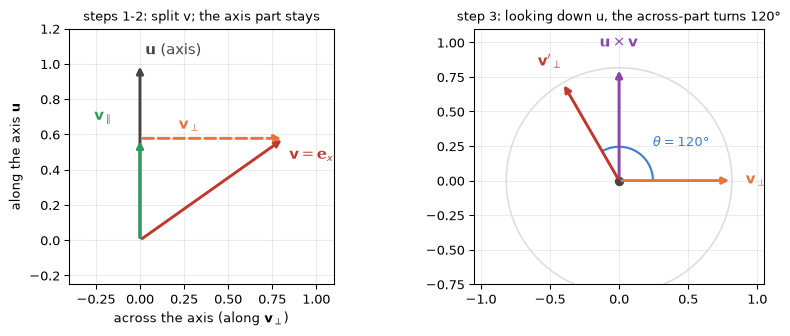

In [20]:
v = np.array([1.0, 0.0, 0.0])
u = diag
v_par = (u @ v) * u                       # step 1
v_perp = v - v_par
w = np.cross(u, v)                        # step 3's second arrow
th120 = np.radians(120)
v_new = v_par + np.cos(th120) * v_perp + np.sin(th120) * w     # step 4

print("   ".join(f"{name} {tidy(vec)} (|{np.linalg.norm(vec):.3f}|)" for name, vec in
                  (("v_par", v_par), ("v_perp", v_perp), ("u x v", w))))
print(f"v' = {tidy(v_new)}    vs R120 @ x: {np.abs(v_new - R120 @ v).max():.1e}")

e1, e2 = v_perp / np.linalg.norm(v_perp), w / np.linalg.norm(w)   # the turning plane
fig, axs = plt.subplots(1, 2, figsize=(9.0, 3.6))
ax = axs[0]                                # side view: the plane holding u and v
for vec, lab, c, off in ((u, r"$\mathbf{u}$ (axis)", "#444", (0.03, 0.05)),
                         (v_par, r"$\mathbf{v}_\parallel$", "#2a9d5c", (-0.26, 0.10)),
                         (v, r"$\mathbf{v}=\mathbf{e}_x$", "#c0392b", (0.03, -0.12))):
    xy = np.array([vec @ e1, vec @ u])
    ax.annotate("", xy=xy, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=c, lw=2.2))
    ax.text(*(xy + off), lab, color=c, fontsize=11)
base = np.array([0, v_par @ u])
ax.annotate("", xy=[v @ e1, v @ u], xytext=base,
            arrowprops=dict(arrowstyle="-|>", color="#e8743b", lw=2.2, ls="--"))
ax.text(0.22, base[1] + 0.05, r"$\mathbf{v}_\perp$", color="#e8743b", fontsize=11)
ax.set_xlim(-0.4, 1.1); ax.set_ylim(-0.25, 1.2); ax.set_aspect("equal"); ax.grid(alpha=0.25)
ax.set_xlabel(r"across the axis (along $\mathbf{v}_\perp$)"); ax.set_ylabel(r"along the axis $\mathbf{u}$")
ax.set_title("steps 1-2: split v; the axis part stays", fontsize=10)

ax = axs[1]                                # looking straight down the axis
r = np.linalg.norm(v_perp)
circ = np.linspace(0, 2 * np.pi, 200)
ax.plot(r * np.cos(circ), r * np.sin(circ), color="#ddd", lw=1.2)
for vec, lab, c in ((v_perp, r"$\mathbf{v}_\perp$", "#e8743b"), (w, r"$\mathbf{u}\times\mathbf{v}$", "#8e44ad"),
                    (v_new - v_par, r"$\mathbf{v}'_\perp$", "#c0392b")):
    xy = np.array([vec @ e1, vec @ e2])
    ax.annotate("", xy=xy, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=c, lw=2.2))
    ax.text(*(xy * 1.22), lab, color=c, fontsize=11, ha="center", va="center")
arc = np.linspace(0, th120, 40)
ax.plot(0.3 * r * np.cos(arc), 0.3 * r * np.sin(arc), color="#3b7dd8", lw=1.6)
ax.text(0.30 * r, 0.30 * r, r"$\theta=120°$", color="#3b7dd8", fontsize=10)
ax.plot(0, 0, "o", color="#444", ms=6)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-0.75, 1.1); ax.set_aspect("equal"); ax.grid(alpha=0.25)
ax.set_title("step 3: looking down u, the across-part turns 120°", fontsize=10)
fig.tight_layout(); plt.show()

$\mathbf{v}_\parallel = \tfrac13(1,1,1)$; $\mathbf{v}_\perp$ and
$\mathbf{u}\times\mathbf{v}$ are the turning plane’s two perpendicular
arrows, both of length $0.816$. Turned across-part plus untouched
along-part lands exactly on $\mathbf{e}_y$.

------------------------------------------------------------------------

## Axis-angle $\to R$: Rodrigues’ formula, in code

For a **unit** axis $\mathbf{u}$ and angle $\theta$:

$$R = I\cos\theta \;+\; (1-\cos\theta)\,\mathbf{u}\mathbf{u}^{\top} \;+\; [\mathbf{u}]_{\times}\sin\theta,
\qquad
[\mathbf{u}]_{\times} = \begin{bmatrix} 0 & -u_z & u_y \\ u_z & 0 & -u_x \\ -u_y & u_x & 0\end{bmatrix}$$

Three pieces, one per step of the derivation: $I\cos\theta$ and
$-\cos\theta\,\mathbf{u}\mathbf{u}^{\top}$ shrink the across-part,
$\mathbf{u}\mathbf{u}^{\top}$ keeps the along-part, and
$[\mathbf{u}]_{\times}\sin\theta$ swings the across-part sideways.
Written out and checked against MuJoCo:

In [21]:
def rodrigues(u, theta):
    u = np.asarray(u, float)
    u = u / np.linalg.norm(u)                    # the formula needs a UNIT axis
    K = np.array([[0, -u[2], u[1]],
                  [u[2], 0, -u[0]],
                  [-u[1], u[0], 0]])             # the cross-product matrix
    return (np.eye(3) * np.cos(theta)
            + (1 - np.cos(theta)) * np.outer(u, u)
            + K * np.sin(theta))

R_rod = rodrigues(diag, np.radians(120))
for row in tidy(R_rod):
    print("   ", row)
print(f"\nmatches MuJoCo: {np.abs(R_rod - R120).max():.1e}")

    [0. 0. 1.]
    [1. 0. 0.]
    [0. 1. 0.]

matches MuJoCo: 2.2e-16

With $\theta = 120°$: $\cos\theta = -\tfrac12$ and
$\sin\theta = \tfrac{\sqrt3}{2}$, and since
$u_x = u_y = u_z = \tfrac{1}{\sqrt3}$ every entry of
$\mathbf{u}\mathbf{u}^{\top}$ is $\tfrac13$ — which is why the answer
comes out in clean $0$s and $1$s.

------------------------------------------------------------------------

## Quaternion $\to R$

For a **unit** quaternion $q = (w, x, y, z)$:

$$R = \begin{bmatrix}
1-2(y^2+z^2) & 2(xy - wz) & 2(xz + wy)\\
2(xy + wz) & 1-2(x^2+z^2) & 2(yz - wx)\\
2(xz - wy) & 2(yz + wx) & 1-2(x^2+y^2)
\end{bmatrix}$$

Every entry is quadratic in the components — which is exactly why $q$
and $-q$ give the same $R$: every term has two factors, so the signs
cancel.

In [22]:
def quat_to_R(q):
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - w*z),     2*(x*z + w*y)],
        [2*(x*y + w*z),     1 - 2*(x*x + z*z), 2*(y*z - w*x)],
        [2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x*x + y*y)]])

R_quat = quat_to_R(q120)
for row in tidy(R_quat):
    print("   ", row)
print(f"\nmatches MuJoCo: {np.abs(R_quat - R120).max():.1e}")

    [0. 0. 1.]
    [1. 0. 0.]
    [0. 1. 0.]

matches MuJoCo: 1.1e-16

With $w = x = y = z = \tfrac12$ every product is $\tfrac14$, so each
diagonal entry is $1 - 2(\tfrac14 + \tfrac14) = 0$, each
$2(xy - wz) = 0$, and each $2(xy + wz) = 1$. Hence the permutation
matrix.

The rotation is also written $v' = q\,v\,q^{-1}$ — the same operation as
$Rv$, which is why we convert once and then use the matrix.

------------------------------------------------------------------------

## Euler $\to R$: multiply three matrices

MuJoCo’s lowercase `'xyz'` is **intrinsic**, so the three turns compose
left to right:

$$R = R_x(\text{roll})\,R_y(\text{pitch})\,R_z(\text{yaw})$$

$$R_x(90°) = \begin{bmatrix}1&0&0\\0&0&-1\\0&1&0\end{bmatrix},\quad
R_y(90°) = \begin{bmatrix}0&0&1\\0&1&0\\-1&0&0\end{bmatrix},\quad
R_z(0°) = I$$

In [23]:
def Ry(t):
    return np.array([[np.cos(t), 0, np.sin(t)], [0, 1, 0], [-np.sin(t), 0, np.cos(t)]])

R_euler = Rx(np.radians(90)) @ Ry(np.radians(90)) @ Rz(np.radians(0))
for row in tidy(R_euler):
    print("   ", row)
print(f"\nmatches MuJoCo: {np.abs(R_euler - R120).max():.1e}")
print(f"all three hand conversions agree: "
      f"{np.allclose(R_rod, R_quat) and np.allclose(R_quat, R_euler)}")

    [0. 0. 1.]
    [1. 0. 0.]
    [0. 1. 0.]

matches MuJoCo: 1.1e-16
all three hand conversions agree: True

**The order of the product is the convention.** Reverse it and you get a
different, equally legal rotation — this is the “dozen conventions” line
in the table, made concrete.

------------------------------------------------------------------------

## What $R$ actually does

All three forms converge on one matrix, and the matrix is the thing that
acts on a vector:

$$\mathbf{v}' = R\,\mathbf{v}
\qquad\Longrightarrow\qquad
\begin{bmatrix}x'\\y'\\z'\end{bmatrix}
=\begin{bmatrix}0&0&1\\1&0&0\\0&1&0\end{bmatrix}
\begin{bmatrix}x\\y\\z\end{bmatrix}
=\begin{bmatrix}z\\x\\y\end{bmatrix}$$

In [24]:
for v in ([1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 2, 3]):
    print(f"   R @ {str(v):10s} = {tidy(R120 @ np.array(v, float))}")

   R @ [1, 0, 0]  = [0. 1. 0.]
   R @ [0, 1, 0]  = [0. 0. 1.]
   R @ [0, 0, 1]  = [1. 0. 0.]
   R @ [1, 2, 3]  = [3. 1. 2.]

Read the last line: the rotation copies $z$ into the new $x$ slot, $x$
into $y$, and $y$ into $z$. That is the $x \to y \to z \to x$ cycle, now
as arithmetic.

**This is the only operation we ever need.** `my_fk` calls it once per
link — `rot @ model.body_pos[bid]` is exactly $R\mathbf{v}$, and nothing
else in forward kinematics does anything more exotic.

------------------------------------------------------------------------

## Why a matrix needs nine numbers for three freedoms

A rotation has three degrees of freedom. The matrix spends nine, so six
of them must be spoken for — and they are, by a constraint you can
check:

In [25]:
print("R @ R.T  (should be the identity):")
for row in tidy(R120 @ R120.T):
    print("   ", row)
print(f"\nmax deviation from identity : {np.abs(R120 @ R120.T - np.eye(3)).max():.1e}")
print(f"determinant                 : {np.linalg.det(R120):.6f}   <- +1, not -1")
print(f"length of each column       : {np.round(np.linalg.norm(R120, axis=0), 6)}")

R @ R.T  (should be the identity):
    [1. 0. 0.]
    [0. 1. 0.]
    [0. 0. 1.]

max deviation from identity : 1.2e-32
determinant                 : 1.000000   <- +1, not -1
length of each column       : [1. 1. 1.]

Columns of unit length, mutually perpendicular: $3 + 3 = 6$ constraints
on $9$ numbers, leaving $3$. A determinant of $-1$ would be a
**reflection** — a mirrored robot, not a turned one.

The quaternion does the same bookkeeping with one constraint on four
numbers, $\|q\| = 1$ — which is exactly the `nq` versus `nv` gap from
Week 1.

------------------------------------------------------------------------

## Two ways a quaternion bites

In [26]:
print("1. SIGN:  q and -q are the SAME rotation")
print("   q  =", np.round(q120, 4), "  ->  -q =", np.round(-q120, 4))
print(f"   max |R(q) - R(-q)| = {np.abs(quat2mat(q120) - quat2mat(-q120)).max():.1e}")
print("   so you cannot compare orientations by comparing quaternion numbers.\n")

print("2. ORDER:  MuJoCo is scalar-FIRST. SciPy, ROS and most engines are scalar-LAST.")
dq = soc4180.keyframe_data(model, "stand")
dq.qpos[idx] = [-0.30, 0.10, 0.05, 0.70, -0.35, 0.02]
mujoco.mj_forward(model, dq)
q_foot = np.zeros(4)
mujoco.mju_mat2Quat(q_foot, dq.site_xmat[kin.foot_site_id(model, "left")])
misread = np.r_[q_foot[3], q_foot[:3]]          # scalar taken from the wrong end

def turn_angle(R):
    return np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1, 1)))

print("   the foot's real orientation (w,x,y,z) :", np.round(q_foot, 4))
print("   the same four numbers, read backwards :", np.round(misread, 4))
print(f"   it is tilted {turn_angle(quat2mat(q_foot)):.1f} deg ... "
      f"but read backwards, {turn_angle(quat2mat(misread)):.1f} deg")
print(f"   the foot's down direction: true {np.round(quat2mat(q_foot) @ [0, 0, -1], 2)}"
      f"   misread {np.round(quat2mat(misread) @ [0, 0, -1], 2)}")

1. SIGN:  q and -q are the SAME rotation
   q  = [0.5 0.5 0.5 0.5]   ->  -q = [-0.5 -0.5 -0.5 -0.5]
   max |R(q) - R(-q)| = 0.0e+00
   so you cannot compare orientations by comparing quaternion numbers.

2. ORDER:  MuJoCo is scalar-FIRST. SciPy, ROS and most engines are scalar-LAST.
   the foot's real orientation (w,x,y,z) : [0.9978 0.0419 0.0242 0.0456]
   the same four numbers, read backwards : [0.0456 0.9978 0.0419 0.0242]
   it is tilted 7.6 deg ... but read backwards, 174.8 deg
   the foot's down direction: true [-0.05  0.08 -1.  ]   misread [-0.05  0.09  0.99]

The misread quaternion is still **unit length and a perfectly legal
rotation** — nothing raises, nothing is out of range. It simply turns
the foot upside down.

------------------------------------------------------------------------

## Gimbal lock, measured

Euler angles are readable, and they fail in a specific place. Set
**pitch to 90°** and roll and yaw stop being independent — only their
*sum* survives:

In [27]:
def from_euler(roll, pitch, yaw):
    q = np.zeros(4)
    mujoco.mju_euler2Quat(q, np.radians([roll, pitch, yaw]).astype(float), "xyz")
    return q

print("pitch = 90 deg:")
for roll, yaw in [(30, 0), (0, 30), (15, 15), (45, -15)]:
    print(f"   roll {roll:+4d}, yaw {yaw:+4d}  (sum {roll + yaw:+4d})  ->  "
          f"quat {np.round(from_euler(roll, 90, yaw), 4)}")

print("\nand it is not a knife edge — the degeneracy fades slowly:")
for pitch in (90, 89, 80, 60):
    a, b = quat2mat(from_euler(30, pitch, 0)), quat2mat(from_euler(0, pitch, 30))
    print(f"   pitch {pitch:3d} deg:  (roll 30, yaw 0) and (roll 0, yaw 30) "
          f"differ by {turn_angle(a.T @ b):5.2f} deg")

pitch = 90 deg:
   roll  +30, yaw   +0  (sum  +30)  ->  quat [0.683 0.183 0.683 0.183]
   roll   +0, yaw  +30  (sum  +30)  ->  quat [0.683 0.183 0.683 0.183]
   roll  +15, yaw  +15  (sum  +30)  ->  quat [0.683 0.183 0.683 0.183]
   roll  +45, yaw  -15  (sum  +30)  ->  quat [0.683 0.183 0.683 0.183]

and it is not a knife edge — the degeneracy fades slowly:
   pitch  90 deg:  (roll 30, yaw 0) and (roll 0, yaw 30) differ by  0.00 deg
   pitch  89 deg:  (roll 30, yaw 0) and (roll 0, yaw 30) differ by  0.52 deg
   pitch  80 deg:  (roll 30, yaw 0) and (roll 0, yaw 30) differ by  5.17 deg
   pitch  60 deg:  (roll 30, yaw 0) and (roll 0, yaw 30) differ by 15.36 deg

Four different pairs of angles, **one identical rotation**. A control
law that commands roll and yaw separately has, at that pitch, one knob
doing nothing — and near it, one knob doing almost nothing.

**This is why we compose matrices and store quaternions**, and never
hand a controller three Euler angles.

------------------------------------------------------------------------

## Why `nq` is bigger than `nv`

You met this gap in Week 1. Here is the consequence that matters this
week:

In [28]:
print(f"nq = {model.nq}   nv = {model.nv}   difference = {model.nq - model.nv}")
print(f"floating base qpos = {np.round(data.qpos[:7], 3)}")
print(f"                     = 3 position + 4 quaternion")
print(f"quaternion norm    = {np.linalg.norm(data.qpos[3:7]):.6f}   <- always exactly 1")

nq = 36   nv = 35   difference = 1
floating base qpos = [0.   0.   0.79 1.   0.   0.   0.  ]
                     = 3 position + 4 quaternion
quaternion norm    = 1.000000   <- always exactly 1

Four numbers, three freedoms, because the quaternion is pinned to unit
length.

**So positions and velocities live in different-sized spaces**, and
`qpos += qvel * dt` is not merely inaccurate — the shapes do not even
match. To advance a rotation you need `mj_integratePos`, which knows to
*rotate* the quaternion rather than add to it. Next week’s IK computes
its step in velocity space and has to apply it in position space; this
is why.

------------------------------------------------------------------------

## The body tree is the robot

Week 1 showed the tree that the XML nesting draws. Here is that same
tree with the numbers forward kinematics actually consumes — each body’s
**fixed offset from its parent**, and the **axis** its joint turns
about:

In [29]:
for bid in kin.leg_chain(model, "left"):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, bid)
    jnt = model.body_jntadr[bid]
    axis = model.jnt_axis[jnt] if jnt >= 0 else None
    print(f"  {name:24s} offset={np.round(model.body_pos[bid], 4)}  axis={axis}")

  left_hip_pitch_link      offset=[ 0.      0.0645 -0.1027]  axis=[0. 1. 0.]
  left_hip_roll_link       offset=[ 0.      0.052  -0.0305]  axis=[1. 0. 0.]
  left_hip_yaw_link        offset=[ 0.025   0.     -0.1241]  axis=[0. 0. 1.]
  left_knee_link           offset=[-0.0783  0.0021 -0.1773]  axis=[0. 1. 0.]
  left_ankle_pitch_link    offset=[ 0.e+00 -1.e-04 -3.e-01]  axis=[0. 1. 0.]
  left_ankle_roll_link     offset=[ 0.      0.     -0.0176]  axis=[1. 0. 0.]

Each row is one link: *go here* (the offset), *then turn about this*
(the axis). Six rows, hip to foot. The axes are Week 1’s roll, pitch and
yaw — $x$, $y$, $z$ respectively — so the leg’s whole design is readable
straight off the table.

------------------------------------------------------------------------

## Forward kinematics, by hand

Now walk the chain, carrying a running position and rotation. For each
body: apply its fixed offset, then rotate about its joint.

In [30]:
def axis_angle(axis, angle):
    """Rotation matrix for turning `angle` radians about `axis`."""
    q = np.zeros(4)
    mujoco.mju_axisAngle2Quat(q, np.asarray(axis, float), float(angle))
    return quat2mat(q)

def my_fk(model, qpos, side="left"):
    pos = qpos[:3].copy()                           # start at the pelvis...
    rot = quat2mat(qpos[3:7])                       # ...facing wherever it faces
    for bid in kin.leg_chain(model, side):
        pos = pos + rot @ model.body_pos[bid]       # step to the next joint
        rot = rot @ quat2mat(model.body_quat[bid])  # apply any built-in tilt
        jnt = model.body_jntadr[bid]
        if jnt >= 0:
            a = model.jnt_pos[jnt]                  # where the axis sits in the body
            Rj = axis_angle(model.jnt_axis[jnt], qpos[model.jnt_qposadr[jnt]])
            pos = pos + rot @ (a - Rj @ a)          # rotate about the anchor, not the origin
            rot = rot @ Rj                          # ...and carry the turn onward
    s = kin.foot_site_id(model, side)
    return pos + rot @ model.site_pos[s]            # finally, out to the foot site

Twelve lines, and every one of them is $\mathbf{p} \mapsto R\mathbf{p} +
\mathbf{t}$ from the transform slide: `pos = pos + rot @ offset` is
${\color{#2a9d5c}{\mathbf{t}_{ac}}} = {\color{#e8743b}{R_{ab}}}{\color{#2a9d5c}{\mathbf{t}_{bc}}} + {\color{#2a9d5c}{\mathbf{t}_{ab}}}$,
and `rot = rot @ ...` is
${\color{#e8743b}{R_{ac}}} = {\color{#e8743b}{R_{ab}R_{bc}}}$. **`rot`
always means “how the current link is turned, in world coordinates”** —
which is why every offset is multiplied by it before being added.

------------------------------------------------------------------------

## Check it against MuJoCo

Never trust kinematics you have not validated. Pick a pose with
**nothing at zero**, so the test cannot pass by accident:

In [31]:
data.qpos[idx] = [-0.30, 0.10, 0.05, 0.70, -0.35, 0.02]   # roll and yaw switched on
mujoco.mj_forward(model, data)

mine = my_fk(model, data.qpos, "left")
theirs = data.site_xpos[kin.foot_site_id(model, "left")]

print(f"my forward kinematics : {np.round(mine, 10)}")
print(f"mujoco  site_xpos     : {np.round(theirs, 10)}")
print(f"max absolute error    : {np.abs(mine - theirs).max():.2e}")

my forward kinematics : [-0.01850933  0.1535268   0.0730434 ]
mujoco  site_xpos     : [-0.01850933  0.1535268   0.0730434 ]
max absolute error    : 1.80e-16

**Agreement to machine precision** — around $10^{-16}$, a hundred
million times tighter than the paper model, and on a pose the paper
model could not describe at all. Not “close enough”: the *same*
floating-point answer, because it is the same computation.

If your own version disagrees, it is almost always **composition order**
or a **scalar-last quaternion**. The third candidate — the joint anchor
— cannot bite you on this robot, and a slide below explains why that is
worth knowing.

------------------------------------------------------------------------

## The same chain, as one product of $4\times4$ matrices

Each body contributes two factors: its **fixed mount** (offset and
built-in tilt, from the MJCF) and its **joint** (a pure turn by
${\color{#3b7dd8}{q_j}}$ about the axis). The leg is their product, left
to right, pelvis to foot, ending with the foot site’s own offset
$\mathbf{s}$ inside the last body:

$${\color{#8e44ad}{T_{\text{world}\leftarrow\text{foot}}}} = {\color{#8e44ad}{T_{\text{pelvis}}}}\;\prod_{k=1}^{6}\Big[\underbrace{{\color{#8e44ad}{T}}\big({\color{#e8743b}{R_{\text{mount},k}}},\,{\color{#2a9d5c}{\mathbf{t}_{\text{mount},k}}}\big)}_{\text{the mount, from the MJCF}}\;\underbrace{{\color{#8e44ad}{T}}\big({\color{#e8743b}{R_{\text{axis}_k}({\color{#3b7dd8}{q_k}})}},\,\mathbf{0}\big)}_{\text{the joint}}\Big]\;{\color{#8e44ad}{T}}\big(I,\,\mathbf{s}\big)$$

In [32]:
# mount = body_quat + body_pos;  s = site_pos, the foot site's offset in its body
T_run = make_T(quat2mat(data.qpos[3:7]), data.qpos[:3])       # the pelvis
frames_T = [("pelvis", T_run.copy())]
for bid in kin.leg_chain(model, "left"):
    T_run = T_run @ make_T(quat2mat(model.body_quat[bid]), model.body_pos[bid])   # mount
    jnt = model.body_jntadr[bid]
    T_run = T_run @ make_T(axis_angle(model.jnt_axis[jnt],
                                      data.qpos[model.jnt_qposadr[jnt]]), np.zeros(3))  # joint
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, bid)
    frames_T.append((name, T_run.copy()))
    print(f"  {name:24s} position error {np.abs(T_run[:3, 3] - data.xpos[bid]).max():.1e}"
          f"   rotation error {np.abs(T_run[:3, :3] - data.xmat[bid].reshape(3, 3)).max():.1e}")

foot_T = T_run @ np.r_[model.site_pos[kin.foot_site_id(model, 'left')], 1.0]
print(f"\n  foot site                position error "
      f"{np.abs(foot_T[:3] - data.site_xpos[kin.foot_site_id(model, 'left')]).max():.1e}")

  left_hip_pitch_link      position error 0.0e+00   rotation error 0.0e+00
  left_hip_roll_link       position error 0.0e+00   rotation error 1.1e-16
  left_hip_yaw_link        position error 1.4e-17   rotation error 2.2e-16
  left_knee_link           position error 5.6e-17   rotation error 6.7e-16
  left_ankle_pitch_link    position error 1.7e-16   rotation error 6.7e-16
  left_ankle_roll_link     position error 1.8e-16   rotation error 6.7e-16

  foot site                position error 1.8e-16

Every intermediate frame matches MuJoCo’s own `xpos` and `xmat` — not
just the foot. That is the advantage of the matrix form: the product *up
to body $k$* is body $k$’s pose, so you get all six frames for free on
the way down.

------------------------------------------------------------------------

## Six frames down the leg, drawn

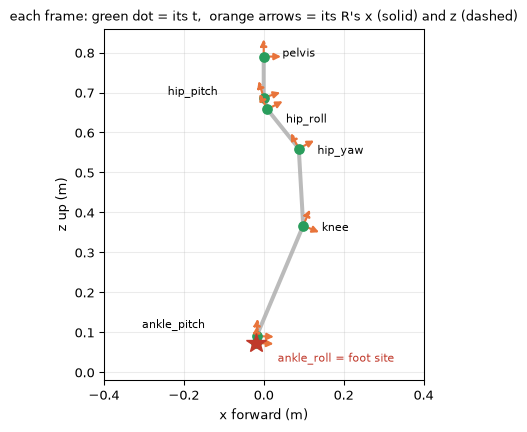

In [33]:
fig, ax = plt.subplots(figsize=(7.0, 4.6))
chain_xyz = np.array([T[:3, 3] for _, T in frames_T] + [foot_T[:3]])
ax.plot(chain_xyz[:, 0], chain_xyz[:, 2], color="#bbb", lw=3, zorder=1)
label_at = {"pelvis": (14, 0), "hip_pitch": (-72, 2), "hip_roll": (14, -10),
            "hip_yaw": (14, -4), "knee": (14, -4), "ankle_pitch": (-86, 6),
            "ankle_roll": (16, -14)}
for name, T in frames_T:
    o = T[:3, 3]
    for col, style in ((0, "-"), (2, "--")):              # the frame's own x and z axes
        tip = o + 0.05 * T[:3, col]
        ax.annotate("", xy=(tip[0], tip[2]), xytext=(o[0], o[2]),
                    arrowprops=dict(arrowstyle="-|>", color="#e8743b", lw=1.6, ls=style))
    ax.plot(o[0], o[2], "o", ms=7, color="#2a9d5c", zorder=3)
    short = name.replace("left_", "").replace("_link", "")
    ax.annotate(short if short != "ankle_roll" else "ankle_roll = foot site", (o[0], o[2]),
                textcoords="offset points", xytext=label_at[short], fontsize=8.5,
                color="#c0392b" if short == "ankle_roll" else "k")
ax.plot(foot_T[0], foot_T[2], "*", ms=15, color="#c0392b", zorder=4)
ax.set_aspect("equal"); ax.grid(alpha=0.25)
ax.set_xlim(-0.40, 0.40); ax.set_ylim(-0.02, 0.86)
ax.set_xlabel("x forward (m)"); ax.set_ylabel("z up (m)")
ax.set_title("each frame: green dot = its t,  orange arrows = its R's x (solid) and z (dashed)",
             fontsize=9.5)
fig.tight_layout(); plt.show()

Each dashed $z$ arrow is the previous frame’s, turned by one more
factor. Two mounts are tilted in the MJCF itself: `body_quat` turns the
hip-roll link $-10°$ about $y$ and the knee link $+10°$. Roll and yaw
are on in this pose too, but they mostly turn frames out of the page,
where a side view cannot show them.

------------------------------------------------------------------------

## The line that does nothing

Delete `pos = pos + rot @ (a - Rj @ a)` from `my_fk` and the answer does
not change. Every joint in the G1 is anchored at its body’s origin:

In [34]:
nonzero = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, j)
           for j in range(model.njnt) if not np.allclose(model.jnt_pos[j], 0)]
print(f"{model.njnt} joints; with a non-zero anchor: {nonzero or 'none'}")

30 joints; with a non-zero anchor: none

So `a` is the zero vector, `a - Rj @ a` is zero, and the term is dead
code — **on this robot**. MJCF lets you put the joint anywhere inside
the body, and then it is not dead at all. A link hinged at its far end,
of the kind you wrote last week:

In [35]:
XML = """<mujoco><worldbody>
  <body name="link" pos="0 0 1">
    <joint name="h" type="hinge" axis="0 1 0" pos="0.3 0 0"/>
    <geom type="capsule" fromto="0 0 0 0.3 0 0" size=".02"/>
    <site name="tip" pos="0.3 0 0"/>
  </body>
</worldbody></mujoco>"""
m2 = mujoco.MjModel.from_xml_string(XML)
d2 = mujoco.MjData(m2)
d2.qpos[0] = 0.8
mujoco.mj_forward(m2, d2)

a = m2.jnt_pos[0]
Rj = axis_angle(m2.jnt_axis[0], d2.qpos[0])
base = m2.body_pos[1]
with_anchor    = base + (a - Rj @ a) + Rj @ m2.site_pos[0]
without_anchor = base + Rj @ m2.site_pos[0]

print(f"mujoco says    : {np.round(d2.site_xpos[0], 6)}")
print(f"with anchor    : {np.round(with_anchor, 6)}")
print(f"without anchor : {np.round(without_anchor, 6)}   <- off by "
      f"{np.abs(without_anchor - d2.site_xpos[0]).max():.3f} m")

mujoco says    : [0.3 0.  1. ]
with anchor    : [0.3 0.  1. ]
without anchor : [0.209012 0.       0.784793]   <- off by 0.215 m

------------------------------------------------------------------------

## Why 21 cm

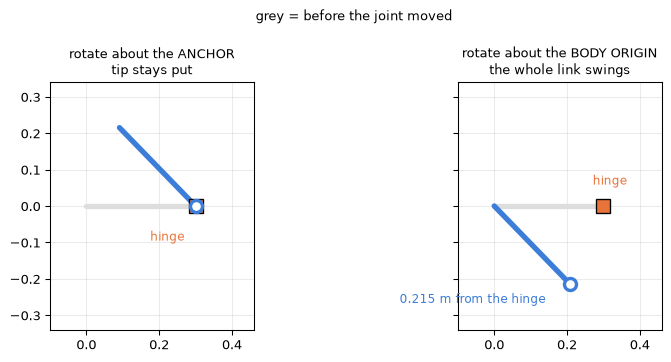

In [36]:
def R2(t):
    return np.array([[np.cos(t), np.sin(t)], [-np.sin(t), np.cos(t)]])

pivot, tip, theta = np.array([0.3, 0.0]), np.array([0.3, 0.0]), 0.8
fig, axs = plt.subplots(1, 2, figsize=(9.0, 3.8), sharex=True, sharey=True)
for ax, use_anchor in zip(axs, (True, False)):
    ax.plot([0, 0.3], [0, 0], lw=4, color="#ddd", solid_capstyle="round")   # before
    R = R2(theta)
    shift = (pivot - R @ pivot) if use_anchor else np.zeros(2)
    p0, p1 = shift, shift + R @ tip
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=4, color="#3b7dd8", solid_capstyle="round")
    ax.plot(*pivot, "s", ms=11, color="#e8743b", mec="k", zorder=4)
    ax.plot(*p1, "o", ms=9, color="w", mec="#3b7dd8", mew=2.5, zorder=6)
    ax.set_title("rotate about the ANCHOR\ntip stays put" if use_anchor
                 else "rotate about the BODY ORIGIN\nthe whole link swings", fontsize=10)
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.annotate("hinge", pivot, textcoords="offset points",
                xytext=(-34, -26) if use_anchor else (-8, 16),
                fontsize=9, color="#e8743b")
axs[1].annotate(f"{np.abs(without_anchor - d2.site_xpos[0]).max():.3f} m from the hinge",
                p1, textcoords="offset points", xytext=(-128, -14),
                fontsize=9, color="#3b7dd8")
axs[0].set_xlim(-0.10, 0.46); axs[0].set_ylim(-0.34, 0.34)
fig.suptitle("grey = before the joint moved", fontsize=10)
fig.tight_layout(); plt.show()

The site sits **on** the axis, so turning the joint must not move it at
all. Drop the anchor and the link pivots about the wrong point, carrying
the tip 21 cm away. Keep the term: it costs nothing on the G1, and it is
the difference between right and wrong on a robot you write yourself.

------------------------------------------------------------------------

## The workspace

You now have a function from angles to position. Call it three thousand
times with random *legal* angles and you get the set of places the foot
**can** be:

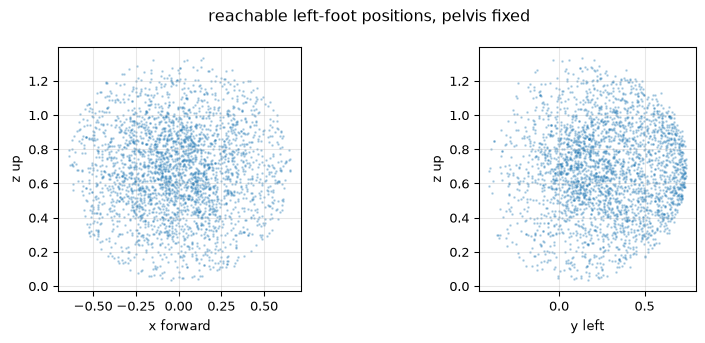

In [37]:
soc4180.set_seed(4180)
jids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, f"left_{j}") for j in kin.LEG_JOINTS]
lo, hi = model.jnt_range[jids, 0], model.jnt_range[jids, 1]

q = data.qpos.copy()
q[:3] = [0, 0, 0.793]                 # park the pelvis, so we see the leg alone
q[3:7] = [1, 0, 0, 0]
pts = []
for _ in range(3000):
    q[idx] = np.random.uniform(lo, hi)
    pts.append(my_fk(model, q, "left"))
pts = np.array(pts)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].scatter(pts[:, 0], pts[:, 2], s=1, alpha=0.25)
ax[0].set_xlabel("x forward"); ax[0].set_ylabel("z up")
ax[1].scatter(pts[:, 1], pts[:, 2], s=1, alpha=0.25)
ax[1].set_xlabel("y left"); ax[1].set_ylabel("z up")
for a_ in ax:
    a_.set_aspect("equal"); a_.grid(alpha=0.3)
fig.suptitle("reachable left-foot positions, pelvis fixed")
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Reading the workspace

The cloud is **not** a ball, and its shape is telling you about the
robot:

- It is **bounded by joint limits**, not by link lengths alone — the
  knee bends only one way, so whole regions are simply missing
- It is **denser in the middle**: many combinations of angles reach the
  centre, very few reach the edges

Two consequences that matter later:

- A foot target near the boundary is reachable by essentially **one**
  posture, so no freedom is left over for balance or for avoiding an
  obstacle
- Near the boundary the leg is nearly **straight**, and there small foot
  motions demand enormous joint motions

That second point is the **singularity** that dominates next week — and
it is why the Week 4 walker crouches instead of standing tall. The next
two slides turn it into a number.

------------------------------------------------------------------------

## The Jacobian, in millimetres

Forget the name for a moment and ask a concrete question: **if I nudge
one joint by half a degree, how far does the foot move?** Measure it by
simply doing it — this is a *derivative* being taken by hand, and the
next slide names it:

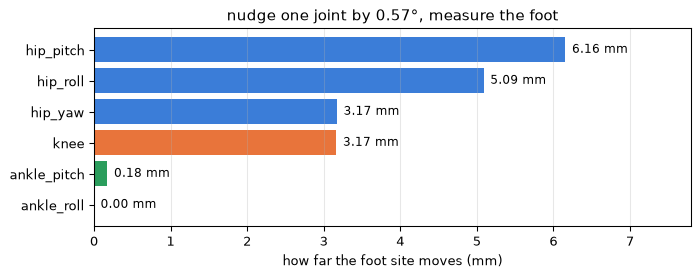

In [38]:
d = soc4180.keyframe_data(model, "stand")
d.qpos[idx] = crouch                      # hip -0.35, knee 0.70, ankle -0.35
mujoco.mj_forward(model, d)
p0 = d.site_xpos[kin.foot_site_id(model, "left")].copy()

moved_mm = []
for k, name in enumerate(kin.LEG_JOINTS):
    nudged = soc4180.keyframe_data(model, "stand")
    nudged.qpos[idx] = crouch
    nudged.qpos[idx[k]] += 0.01           # 0.01 rad = 0.57 degrees
    mujoco.mj_forward(model, nudged)
    moved_mm.append(np.linalg.norm(nudged.site_xpos[kin.foot_site_id(model, "left")] - p0) * 1000)

fig, ax = plt.subplots(figsize=(7.4, 3.0))
bars = ax.barh([n.replace("_joint", "") for n in kin.LEG_JOINTS], moved_mm,
               color=["#3b7dd8"] * 3 + ["#e8743b"] + ["#2a9d5c"] * 2)
for bar, v in zip(bars, moved_mm):
    ax.annotate(f"{v:.2f} mm", (v, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", va="center", fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 7.8)
ax.set_xlabel("how far the foot site moves (mm)")
ax.set_title("nudge one joint by 0.57°, measure the foot", fontsize=11)
ax.grid(axis="x", alpha=0.3); fig.tight_layout(); plt.show()

Six joints, six different sensitivities. The hip is the big lever; the
ankle barely matters. And `ankle_roll` moves the foot **0.00 mm** — the
foot site sits exactly on that axis, so rolling it changes the foot’s
*orientation* and not its position at all.

------------------------------------------------------------------------

## Divide by the nudge, and it is a derivative

Forward kinematics is a function $\mathbf{x} = f(\mathbf{q})$ — six
angles in, three coordinates out. Its derivative is a $3\times 6$
matrix:

$$J \;=\; \frac{\partial \mathbf{x}}{\partial \mathbf{q}},
\qquad J_{ij} = \frac{\partial x_i}{\partial q_j}$$

We already measured the numerator. **Dividing by the nudge** turns
millimetres into a slope, and the $j$-th column is exactly what we
computed:

$$J\,\mathbf{e}_j \;\approx\; \frac{f(\mathbf{q} + \varepsilon\,\mathbf{e}_j) - f(\mathbf{q})}{\varepsilon}$$

where $\mathbf{e}_j$ is 1 in slot $j$ and 0 elsewhere — “move only joint
$j$”.

In [39]:
def foot_at(angles):
    scratch = soc4180.keyframe_data(model, "stand")
    scratch.qpos[idx] = angles
    mujoco.mj_forward(model, scratch)
    return scratch.site_xpos[kin.foot_site_id(model, "left")].copy()

def jacobian_fd(eps):
    x0 = foot_at(crouch)
    cols = []
    for j in range(6):
        q = list(crouch)
        q[j] += eps                                  # q + eps * e_j
        cols.append((foot_at(q) - x0) / eps)         # one column
    return np.column_stack(cols)

J_fd = jacobian_fd(1e-6)

              # mj_jacSite WRITES INTO the arrays you hand it -- it returns nothing.
              # jac_p gets the position rows, jac_r the orientation rows, and both
              # are (3 x nv): a column for every joint in the robot, not just the leg.
jac_p = np.zeros((3, model.nv))
jac_r = np.zeros((3, model.nv))
mujoco.mj_jacSite(model, d, jac_p, jac_r, kin.foot_site_id(model, "left"))

dofs = kin.leg_dof_indices(model, "left")     # so pick out our six leg columns
J_exact = jac_p[:, dofs]

print("finite differences, eps = 1e-6   (units: metres per radian)")
for row in np.round(J_fd, 4):
    print("   ", row)
print("\nMuJoCo's analytic mj_jacSite:")
for row in np.round(J_exact, 4):
    print("   ", row)
print(f"\nmax difference: {np.abs(J_fd - J_exact).max():.2e}")

finite differences, eps = 1e-6   (units: metres per radian)
    [-0.6156 -0.001  -0.0018 -0.2994 -0.0176  0.    ]
    [ 0.      0.509  -0.3173  0.      0.      0.    ]
    [-0.0125  0.0018 -0.001   0.1029  0.      0.    ]

MuJoCo's analytic mj_jacSite:
    [-0.6156 -0.001  -0.0018 -0.2994 -0.0176  0.    ]
    [ 0.      0.509  -0.3173  0.      0.      0.    ]
    [-0.0125  0.0018 -0.001   0.1029  0.      0.    ]

max difference: 3.08e-07

Row = which coordinate of the foot. Column = which joint. Entry $J_{ij}$
= metres of $x_i$ per radian of $q_j$. **The whole matrix is six of our
nudges, divided.**

------------------------------------------------------------------------

## A derivative is a slope — drawn

Hold five joints at the crouch and sweep **one**, `hip_pitch`, through a
whole radian. The foot’s height ${\color{#c0392b}{z}}$ traces a curve
against ${\color{#3b7dd8}{q_1}}$. One entry of $J$,
$J_{z,\,\text{hip pitch}}$ (row 3, column 1), is the **slope of that
curve** at the crouch:

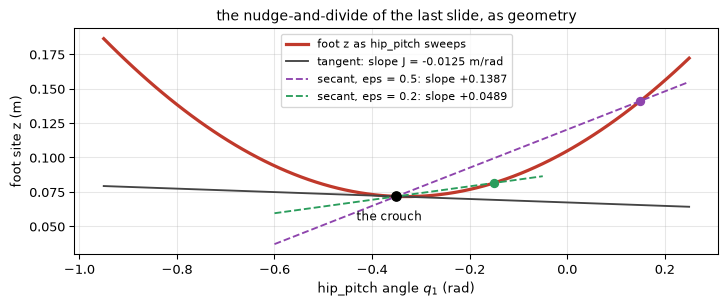

In [40]:
q0 = crouch[0]
sweep = np.linspace(q0 - 0.6, q0 + 0.6, 81)
fz_sweep = np.array([foot_at([s] + list(crouch[1:]))[2] for s in sweep])
z0 = foot_at(crouch)[2]
slope = J_exact[2, 0]                                  # m per rad, from mj_jacSite

fig, ax = plt.subplots(figsize=(7.6, 3.3))
ax.plot(sweep, fz_sweep, color="#c0392b", lw=2.4, label="foot z as hip_pitch sweeps")
ax.plot(sweep, z0 + slope * (sweep - q0), color="#444", lw=1.4,
        label=f"tangent: slope J = {slope:+.4f} m/rad")
for eps, c in ((0.5, "#8e44ad"), (0.2, "#2a9d5c")):
    z1 = foot_at([q0 + eps] + list(crouch[1:]))[2]
    sec = (z1 - z0) / eps
    span = np.array([q0 - 0.25, q0 + eps + 0.1])
    ax.plot(span, z0 + sec * (span - q0), ls="--", color=c, lw=1.4,
            label=f"secant, eps = {eps}: slope {sec:+.4f}")
    ax.plot(q0 + eps, z1, "o", color=c, ms=6)
ax.plot(q0, z0, "o", color="k", ms=7, zorder=5)
ax.annotate("the crouch", (q0, z0), textcoords="offset points", xytext=(-30, -18), fontsize=9)
ax.set_xlabel("hip_pitch angle $q_1$ (rad)"); ax.set_ylabel("foot site z (m)")
ax.grid(alpha=0.3); ax.legend(fontsize=8.5, loc="upper center")
ax.set_title("the nudge-and-divide of the last slide, as geometry", fontsize=10.5)
fig.tight_layout(); plt.show()

A **secant** joins two points on the curve; its slope is (change in
${\color{#c0392b}{z}}$) ÷ (change in ${\color{#3b7dd8}{q}}$) — our nudge
divided. As the nudge ${\varepsilon}$ shrinks, the secant swings onto
the **tangent**, and the tangent’s slope is the derivative. It is almost
flat here — the foot hangs nearly below the hip, so the hip swings it
fore and aft, not up. Swing further and the foot rises: the curve bends,
so $J$ holds only *near* its pose, and next week’s IK recomputes it
after every step.

------------------------------------------------------------------------

## How small should the nudge be?

Instinct says “as small as possible”. Instinct is wrong, and this is
worth seeing once:

$$\text{error} \;\approx\; \underbrace{C\,\varepsilon}_{\text{truncation}} \;+\; \underbrace{u/\varepsilon}_{\text{round-off}}
\qquad\Longrightarrow\qquad \varepsilon_{\text{best}} \approx \sqrt{u} \approx 1.5\times10^{-8}$$

- **Truncation, $C\varepsilon$.** Taylor:
  $f(q+\varepsilon) = f(q) + \varepsilon f'(q) + \tfrac12\varepsilon^2 f''(q) + \dots$
  Subtract $f(q)$, divide by $\varepsilon$: the secant slope is
  $f'(q) + \tfrac12\varepsilon f''(q)$. The error is proportional to
  $\varepsilon$, with $C = \tfrac12|f''|$ — how much the curve bends.
- **Round-off, $u/\varepsilon$.** Each stored $f$ is wrong by about
  $u|f|$, where $u \approx 2.2\times10^{-16}$ is double precision. The
  difference of two nearly equal numbers keeps that absolute error, and
  dividing by $\varepsilon$ magnifies it.
- **The best $\varepsilon$.** Set the derivative of
  $C\varepsilon + u/\varepsilon$ to zero: $C - u/\varepsilon^2 = 0$, so
  $\varepsilon = \sqrt{u/C}$ — and with $C$ and $|f|$ of order one
  (metres, radians), $\sqrt{u}$.

------------------------------------------------------------------------

## How small should the nudge be? Measured

The same finite-difference Jacobian, for eight nudges, against
`mj_jacSite`:

In [41]:
print(f"{'eps':>10}   {'max error vs analytic':>22}")
for eps in (1e-1, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12):
    print(f"{eps:>10.0e}   {np.abs(jacobian_fd(eps) - J_exact).max():>22.3e}")
print(f"\nsqrt(machine epsilon) = {np.sqrt(np.finfo(float).eps):.2e}")

       eps    max error vs analytic
     1e-01                3.077e-02
     1e-02                3.078e-03
     1e-03                3.078e-04
     1e-04                3.078e-05
     1e-06                3.078e-07
     1e-08                1.111e-08
     1e-10                1.564e-06
     1e-12                6.612e-05

sqrt(machine epsilon) = 1.49e-08

Read the two halves. From $10^{-1}$ down to $10^{-8}$ the error falls by
**exactly a factor of ten per decade** — that is the $C\varepsilon$
term, and it is proof the approximation is first-order. Past the minimum
it climbs again: at $10^{-12}$ it is *worse than at* $10^{-4}$.

The best answer is about $10^{-8}$, right where $\sqrt{u}$ predicted.
And this is why we use `mj_jacSite` in real code: **MuJoCo
differentiates the chain analytically**, so there is no $\varepsilon$ to
choose and no error to trade.

------------------------------------------------------------------------

## Each column is a direction the foot can move

A column of $J$ is a **velocity**, not a place: turn joint $j$ at 1
rad/s and the foot sets off along that vector, at that speed. So draw
the six columns from a common origin, to scale, seen from the side and
from above:

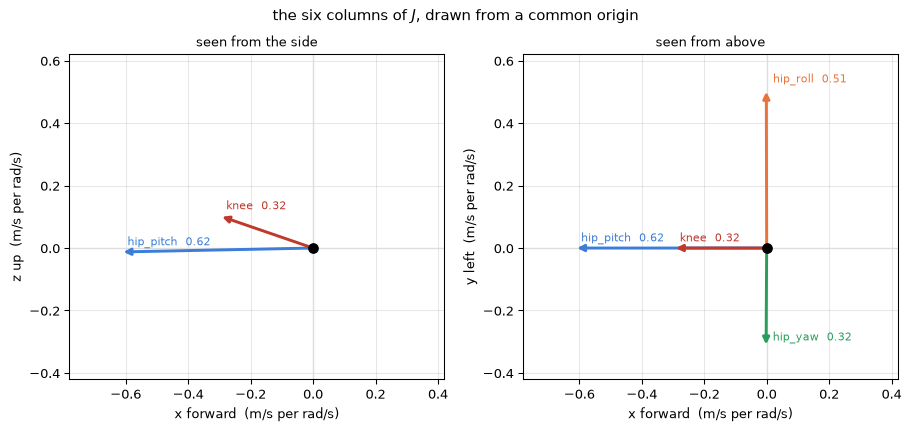

In [42]:
names = [n.replace("_joint", "") for n in kin.LEG_JOINTS]
cols = ["#3b7dd8", "#e8743b", "#2a9d5c", "#c0392b", "#8e44ad", "#7f8c8d"]
views = [((0, 2), "x forward", "z up", "seen from the side"),
         ((0, 1), "x forward", "y left", "seen from above")]

fig, axs = plt.subplots(1, 2, figsize=(9.6, 4.4))
for ax, ((a, b), xlab, ylab, title) in zip(axs, views):
    for j, (nm, c) in enumerate(zip(names, cols)):
        v = J_exact[[a, b], j]
        if np.linalg.norm(v) < 0.02:              # nothing to draw in this view
            continue
        ax.annotate("", xy=v, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=2.2))
        ax.annotate(f"{nm}  {np.linalg.norm(J_exact[:, j]):.2f}", v,
                    textcoords="offset points", xytext=(5, 5), fontsize=8.5, color=c)
    ax.plot(0, 0, "o", ms=7, color="k", zorder=5)
    ax.axhline(0, color="#ddd", lw=1); ax.axvline(0, color="#ddd", lw=1)
    ax.set_xlim(-0.78, 0.42); ax.set_ylim(-0.42, 0.62)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel(f"{xlab}  (m/s per rad/s)"); ax.set_ylabel(f"{ylab}  (m/s per rad/s)")
    ax.set_title(title, fontsize=10)
fig.suptitle("the six columns of $J$, drawn from a common origin", fontsize=11)
fig.tight_layout(); plt.show()

`hip_pitch` is the long arrow — it drives the foot backwards hardest.
`knee` points backwards *and up*. `hip_roll` and `hip_yaw` barely show
from the side and dominate from above: they move the foot **sideways**.

**Both ankle joints are missing**, for two different reasons.
`ankle_pitch` is a 0.02 m/rad stub, too short to draw at this scale —
the 0.18 mm bar. `ankle_roll` is exactly zero: that column has nothing
in it, so there is literally nothing to draw.

Next week’s question is this picture read backwards: given a direction
you *want* the foot to go, **which combination of these six arrows
produces it?**

------------------------------------------------------------------------

## Where a column comes from: axis × lever arm

`mj_jacSite` needs no nudge at all. It uses one fact about turning, in
four steps:

**Step 1 — a hinge turns everything below it about one line.** Joint
$j$’s line passes through its anchor $\mathbf{o}_j$ (MuJoCo:
`data.xanchor[j]`) with unit direction $\mathbf{a}_j$ (`data.xaxis[j]`),
both in world coordinates.

**Step 2 — a point turning about a line moves perpendicular to it.**
Spin at angular velocity $\boldsymbol{\omega}$ and a point at lever arm
$\mathbf{r}$ from the line moves at
$\dot{\mathbf{p}} = \boldsymbol{\omega}\times\mathbf{r}$: speed
$|\boldsymbol{\omega}|$ times its distance from the line, direction
perpendicular to both. (A door handle moves faster than a point by the
hinge.)

**Step 3 — substitute.**
$\boldsymbol{\omega} = \mathbf{a}_j\,{\color{#3b7dd8}{\dot q_j}}$ and
$\mathbf{r} = {\color{#c0392b}{\mathbf{p}}} - \mathbf{o}_j$:
$\;{\color{#c0392b}{\dot{\mathbf{p}}}} = \big(\mathbf{a}_j \times ({\color{#c0392b}{\mathbf{p}}} - \mathbf{o}_j)\big)\,{\color{#3b7dd8}{\dot q_j}}$

**Step 4 — that bracket is column $j$.** Comparing with
${\color{#c0392b}{\dot{\mathbf{x}}}} = J{\color{#3b7dd8}{\dot{\mathbf{q}}}}$:

$$J_{\text{pos},\,j} = \mathbf{a}_j \times ({\color{#c0392b}{\mathbf{p}}} - \mathbf{o}_j),
\qquad J_{\text{rot},\,j} = \mathbf{a}_j$$

In [43]:
p_foot = d.site_xpos[kin.foot_site_id(model, "left")]
print(f"{'joint':14s} {'lever |p-o| (m)':>16s} {'|column| (m/rad)':>17s} {'vs mj_jacSite':>14s}")
for k, bid in enumerate(kin.leg_chain(model, "left")):
    j = model.body_jntadr[bid]
    lever = p_foot - d.xanchor[j]
    col = np.cross(d.xaxis[j], lever)
    print(f"{names[k]:14s} {np.linalg.norm(lever):16.4f} {np.linalg.norm(col):17.4f}"
          f" {np.abs(col - J_exact[:, k]).max():14.1e}")
print(f"rotation rows equal the axes: {np.abs(jac_r[:, dofs] - d.xaxis[[model.body_jntadr[b] for b in kin.leg_chain(model, 'left')]].T).max():.1e}")

joint           lever |p-o| (m)  |column| (m/rad)  vs mj_jacSite
hip_pitch                0.6181            0.6157        0.0e+00
hip_roll                 0.5870            0.5090        6.7e-18
hip_yaw                  0.4988            0.3173        6.7e-18
knee                     0.3166            0.3166        0.0e+00
ankle_pitch              0.0176            0.0176        2.8e-17
ankle_roll               0.0000            0.0000        0.0e+00
rotation rows equal the axes: 0.0e+00

------------------------------------------------------------------------

## Reading the lever-arm table

**Every column matches `mj_jacSite` to the last bit** — the cross
product *is* what MuJoCo computes, with no $\varepsilon$ anywhere.

**A column’s length is the part of the lever *across* the axis.** A
cross product has length $|\mathbf{a}_j|\,|\mathbf{r}|\sin\phi$, with
$\phi$ the angle between axis and lever and $|\mathbf{a}_j| = 1$. So it
measures the foot’s distance from the axis *line*, not from the anchor
point:

- **knee, ankle pitch** — the lever is already across the axis
  ($\phi = 90°$), so column and lever agree: 0.3166 and 0.0176.
- **hip pitch** — the lever is 0.6181 m but includes about 5 cm
  sideways, *along* the $y$ axis, which a turn about $y$ cannot use:
  0.6157 remains.
- **hip roll, hip yaw** — in the crouch their axes are tilted 30°
  (roll’s $x$ axis leans up, yaw’s $z$ axis leans back), so much of the
  lever lies along the axis and is wasted: 0.587 → 0.509, and 0.499 →
  0.317.
- **ankle roll** — the lever is zero: the site is on the axis.

Hip 0.62, knee 0.32, ankle 0.018: the bar chart’s ranking, now
explained.

------------------------------------------------------------------------

## Axis × lever arm, drawn

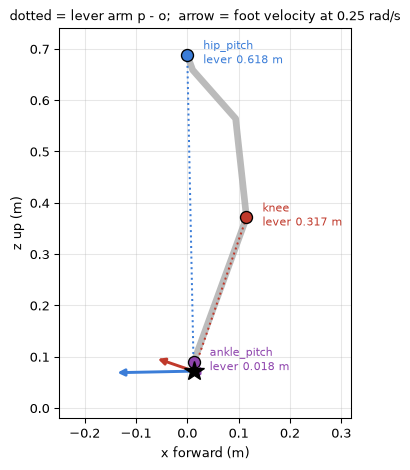

In [44]:
fig, ax = plt.subplots(figsize=(6.6, 5.0))
leg_pts = np.array([d.xanchor[model.body_jntadr[b]] for b in kin.leg_chain(model, "left")] + [p_foot])
ax.plot(leg_pts[:, 0], leg_pts[:, 2], color="#bbb", lw=5, solid_capstyle="round", zorder=1)
for k, c in ((0, "#3b7dd8"), (3, "#c0392b"), (4, "#8e44ad")):     # hip, knee, ankle pitch
    bid = kin.leg_chain(model, "left")[k]
    o = d.xanchor[model.body_jntadr[bid]]
    ax.plot([o[0], p_foot[0]], [o[2], p_foot[2]], ls=":", color=c, lw=1.5)   # the lever arm
    ax.plot(o[0], o[2], "o", color=c, ms=9, mec="k", zorder=3)
    col = J_exact[:, k] * 0.25                                   # drawn at 0.25 rad/s
    ax.annotate("", xy=(p_foot[0] + col[0], p_foot[2] + col[2]), xytext=(p_foot[0], p_foot[2]),
                arrowprops=dict(arrowstyle="-|>", color=c, lw=2.2))
    ax.annotate(f"{names[k]}\nlever {np.linalg.norm(p_foot - o):.3f} m", (o[0], o[2]),
                textcoords="offset points", xytext=(12, -6), fontsize=8.5, color=c)
ax.plot(p_foot[0], p_foot[2], "*", ms=15, color="k", zorder=4)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_xlim(-0.25, 0.32); ax.set_ylim(-0.02, 0.74)
ax.set_xlabel("x forward (m)"); ax.set_ylabel("z up (m)")
ax.set_title("dotted = lever arm p - o;  arrow = foot velocity at 0.25 rad/s", fontsize=10)
fig.tight_layout(); plt.show()

The $y$ axis points into the page, so each pitch joint turns the foot
**perpendicular to its dotted lever**, at a speed proportional to the
lever’s length. The hip’s arrow is long because the hip is far away; the
ankle’s is a stub because the ankle is right above the foot site.

------------------------------------------------------------------------

## The other three rows, and what $J$ is for

A foot pose is six numbers, not three, so the full Jacobian stacks
**three more rows** for orientation — `mj_jacSite` fills both at once.
Read as a rate, it says how fast the foot moves for a given joint speed:

$$\dot{\mathbf{x}} = J(\mathbf{q})\,\dot{\mathbf{q}}$$

In [45]:
J = np.vstack([jac_p, jac_r])[:, dofs]
sv = np.linalg.svd(J, compute_uv=False)
print(f"  full leg Jacobian  : {J.shape}   (3 position + 3 orientation) x 6 joints")
print(f"  singular values    : {np.round(sv, 4)}")
print(f"  largest / smallest : {sv[0]:.4f} / {sv[-1]:.5f}  =  condition number {sv[0]/sv[-1]:.1f}")

d_stand = soc4180.keyframe_data(model, "stand")          # all six leg angles zero
mujoco.mj_forward(model, d_stand)                        # the Jacobian reads x-quantities
jp_s, jr_s = np.zeros((3, model.nv)), np.zeros((3, model.nv))
mujoco.mj_jacSite(model, d_stand, jp_s, jr_s, kin.foot_site_id(model, "left"))
sv_stand = np.linalg.svd(np.vstack([jp_s, jr_s])[:, dofs], compute_uv=False)
print(f"\n  at stand, smallest : {sv_stand[-1]:.2e}   ({sv[-1] / sv_stand[-1]:,.0f} x smaller than crouched)")

  full leg Jacobian  : (6, 6)   (3 position + 3 orientation) x 6 joints
  singular values    : [1.8191 1.4818 1.0002 0.4045 0.4033 0.0887]
  largest / smallest : 1.8191 / 0.08867  =  condition number 20.5

  at stand, smallest : 8.96e-07   (98,915 x smaller than crouched)

A **square** Jacobian: six joints for six freedoms, which is why the
foot can be put anywhere in any orientation. The singular values say how
strongly the foot responds along six independent directions — the
largest is the easiest direction to move, the smallest the hardest.

**When the smallest approaches zero, one direction has stopped
responding.** That is a *singularity*, and next week it is the whole
story: at the `stand` keyframe — every leg joint exactly zero, a
perfectly straight leg — this number collapses to $9\times10^{-7}$,
about 99,000 times smaller than crouched, and inverting $J$ there is
division by almost nothing. (That is exercise 8’s answer; try it before
reading the last line of the output.)

------------------------------------------------------------------------

## Exercises

**Warm-up — do these first**

1.  **Predict, then check.** Using the formula on the paper slide, work
    out by hand where `paper_fk(0.0, 1.0, 0.0)` puts the foot. Then run
    it. Were the signs what you expected?
2.  **Find the straight leg.** Call `paper_fk(0, 0, 0)` and compute the
    distance from hip to foot. Compare it with
    $L_1 + L_2 + \text{foot drop}$. Why do they agree, and what would
    break that agreement?
3.  **Order, again.** Rotate $(1,0,0)$ by $30°$ about $z$ then $30°$
    about $x$, and then in the other order. How far apart are the two
    answers?

**Main**

1.  **Scalar-last.** Change `quat2mat` to read the quaternion as
    $(x,y,z,w)$ and re-run the check. Does the foot land somewhere
    plausible? That plausibility is exactly what makes this bug nasty.
2.  **Break the anchor, properly.** Deleting `(a - Rj @ a)` changes
    nothing on the G1. Edit the toy MJCF so the hinge sits at
    `pos="0.15 0 0"` — the middle of the link — and predict the error
    *before* you run it.
3.  **Orientation too.** Extend `my_fk` to return the foot’s rotation
    matrix as well, and check it against `site_xmat`. You should again
    reach $10^{-16}$.
4.  **Both legs.** Compute the vector from the left foot to the right
    foot **in the pelvis frame**. Verify it is symmetric at the `stand`
    pose, and say what its length means physically.

**Harder**

1.  **Straight-leg check.** Compute the Jacobian’s smallest singular
    value at the `stand` keyframe and at the crouch. Which is closer to
    singular, and by what factor? (The answer is larger than you will
    guess.)
2.  **Workspace volume.** Estimate the reachable volume by Monte Carlo.
    Then ask how much of it survives the requirement that the foot stay
    **flat** — hint: look at `R[2,2]` of the foot’s rotation matrix.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/02-transforms/lab_viewer.py
```

Each pose of `POSES` (SPACE for the next); **green** sphere at MuJoCo’s
foot site, **red** at the file’s own forward kinematics. **Both FKs are
complete and explained** — `chain_fk` (six bodies, 1.8e-16) and
`paper_fk` (three angles, 2.2e-06) — and `F` switches them. Nothing is
simulated.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | add three poses | the foot goes where you predicted; one pose explained from `fk.py` |
| 2 | ENTER on the crouch, then `F` | 1.8e-16, then 2.2e-06, both inside the green sphere |
| 3 | third pose, `F` | the red sphere leaves the foot by 1.2 mm: a planar model cannot know |
| 4 | break `chain_fk` | swap offset and rotation: it moves; drop `(a − Rj a)`: nothing, and why |
| 5 | foot 10 cm forward, still flat | pitch angles summing to zero; then deck `02b`, the lab class’s own |

------------------------------------------------------------------------

## Lab class: `fk.py`, the chain one body at a time

``` bash
uv run weeks/02-transforms/fk.py --angles -0.35 0 0 0.70 -0.35 0
```

Places the leg, walks pelvis → six bodies → foot site by hand, and
prints a line per body: the offset from its parent, the joint, the
angle, and where that leaves us. Then the paper model beside it, then
the pose in the simulator.

    body                      offset from parent (m)  joint          angle   world position after
    pelvis                                                                   [0.     0.     0.79 ]
    left_hip_pitch_link        [0.0, 0.0645, -0.1027] hip_pitch_joint -0.350  [0.     0.0645 0.6873]
    left_hip_roll_link          [0.0, 0.052, -0.0305] hip_roll_joint   0.000  [0.0104 0.1165 0.6587]
    left_hip_yaw_link           [0.025, 0.0, -0.1241] hip_yaw_joint    0.000  [0.0943 0.1165 0.5638]
    left_knee_link         [-0.0783, 0.0021, -0.1773] knee_joint       0.700  [0.1154 0.1186 0.3711]
    left_ankle_pitch_link        [0.0, -0.0001, -0.3] ankle_pitch_joint -0.350 [0.0125 0.1185 0.0893]
    left_ankle_roll_link          [0.0, 0.0, -0.0176] ankle_roll_joint  0.000  [0.0125 0.1185 0.0717]
    chain by hand : [0.012543 0.118506 0.071731]   max error vs MuJoCo 1.8e-16 m
    paper (x, z)  : [0.012545 0.118506 0.071732]   max error vs MuJoCo 2.2e-06 m

Calls, in order: `leg_qpos_indices`, `mj_forward`, `leg_chain`,
`body_pos`, `body_quat`, `jnt_axis`, `mju_quat2Mat`,
`mju_axisAngle2Quat`, `site_pos`, `site_xpos`; then
`launch_viewer(passive=True)` with two `user_scn` spheres.

------------------------------------------------------------------------

## What you built today, in order

Two things, and **one depends on the other**. Keep the arrow pointing
the right way:

$$\underbrace{\mathbf{x} = f(\mathbf{q})}_{\text{forward kinematics}}
\;\xrightarrow{\ \text{differentiate}\ }\;
\underbrace{J = \dfrac{\partial f}{\partial \mathbf{q}}}_{\text{the Jacobian}}$$

**1. Forward kinematics computes positions.** Walk the tree from the
pelvis down, and at each link apply the fixed offset and the joint
rotation, $\mathbf{p} \mapsto R\mathbf{p} + \mathbf{t}$, always relative
to the parent. That is the *only* thing in this course that produces a
position. Twelve lines, and it matched MuJoCo to $10^{-16}$.

**2. The Jacobian computes *change*, not position.** It is the
derivative of step 1 — it answers “if the joints move a little, where
does the foot go?” It cannot tell you where the foot *is*, and it never
could: differentiating throws that away.

And the dependency runs one way only:

In [46]:
calls = 0

def counted_foot(angles):
    global calls
    calls += 1
    return foot_at(angles)

x0 = counted_foot(crouch)
for j in range(6):
    q = list(crouch); q[j] += 1e-6
    _ = counted_foot(q)

print(f"forward-kinematics evaluations needed to build J by hand: {calls}")
print("   1 for the starting position, then 1 per joint")
print("\nso: FK is the primitive. J is measured FROM it, never the reverse.")

forward-kinematics evaluations needed to build J by hand: 7
   1 for the starting position, then 1 per joint

so: FK is the primitive. J is measured FROM it, never the reverse.

Even the “empirical” Jacobian is **seven calls to forward kinematics**.
MuJoCo’s analytic version differentiates the same chain symbolically —
faster, and with no $\varepsilon$ — but it is still $f$ that is being
differentiated.

------------------------------------------------------------------------

## Next week

**Inverse kinematics.** Today: angles in, position out. Next week:
*position in, angles out* — which is harder, sometimes has many answers,
sometimes none, and occasionally blows up entirely.

That is where the Jacobian earns its keep. You cannot invert $f$
directly, but you *can* ask $J$ which way to nudge the joints, take a
small step, and repeat.

We start by inverting the very two-link leg you built on paper today,
with the same $L_1$ and $L_2$ — and then throw it away for a method that
handles all six joints at once.